In [1]:
import argparse
import gzip
import pickle
import matplotlib.pyplot as plt
import yaml
import io
import os
import numpy as np
import hist
from typing import Any, IO, Dict, List, Iterable
import dctools
from dctools import plot as plotter
from dctools.plot import plotting
import matplotlib.pyplot as plt
import scipy.interpolate as interp
import mplhep as hep
from scipy import stats as st
np.seterr(all='warn')
plt.ioff()
from dctools import dict_to_hist_axis


In [3]:
def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear", checksyst=True,
             remap_replacement_types = None, logy=True, logx=False, bin_width_norm=None, no_ratios=False,
             combine_fit="pre-combine", combine_total_uncertainty="total_background", combine_channel_group=None) -> None:
    assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]
    if remap_replacement_types is None:
        remap_replacement_types = [] #expected args: "datadriven", "validation"
    datasets:Dict = dict()
    color_cycle:List = []
    edges:Iterable[str] | Iterable[float] | None = None
    combine_uncertainty_histo: hist.Hist | None = None
    combine_channels: List[str] | None = None
    combine_lumi: int | None = None
    combine_era: str | None = None

    if bin_width_norm is None and "bin_width_norm" in config:
        bin_width_norm = config.bin_width_norm

    for ng, name in enumerate(config.groups):
            histograms = dict(
                filter(
                    lambda _n: _n[0] in config.groups[name].processes,
                    config.boosthist.items()
                )
            )
            p = dctools.datagroup(
                histograms       = histograms,
                ptype            = config.groups[name].type,
                observable       = variable,
                name             = name,
                xsections        = config.xsections,
                channel          = channel,
                luminosity       = config.luminosity.value,
                rebin            = rebin,
                remap_class_name = config.groups[name].remap_class_name if "remap_class_name" in config.groups[name] else None,
            )
           
            if p.remap_replace_group_name is not None:
                if p.remap_replace_type in remap_replacement_types:
                    print(f"Overwriting: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} replaced by {p.name}")
                    # overwrite a previously defined dataset in the dictionary. This requires the remap types to be after ALL MC in the config file (and still before the real data)
                    datasets[p.remap_replace_group_name] = p
                    if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
                        # must replace the previous color cycler...
                        index = list(datasets.keys()).index(p.remap_replace_group_name)
                        color_cycle[index] = config.groups[name].color
                else:
                    print(f"Skipping: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} would have been replaced by {p.name}")
                    # this process is ignored / not added to the stack
                    continue
            else:
                datasets[p.name] = p
                if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
                    color_cycle.append(config.groups[name].color)
            if p.ptype == "signal":
                signal = p.name
    _plot_channel = plotter.add_process_axis(datasets)
    variable_in_axes = variable if variable in _plot_channel.axes.name else ""
    pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'),:,:]
    data = _plot_channel[{'systematic':'nominal'}].project('process', variable_in_axes)[hist.loc('data'),:]
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('data'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('DY'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WW'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ZZ'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('Top'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VVV'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VBFZ'),:])
    # print("data = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('data'),:].sum())
    # print("WZ_ewk = " ,_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:].sum())
    # print("DY = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('DY'),:].sum())
    # print("WW = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WW'),:].sum())
    # print("ZZ = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ZZ'),:].sum())
    # print("WZ = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:].sum())
    # print("Top = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('Top'),:].sum())
    # print("VVV = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VVV'),:].sum())
    # # print("ggVV = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ggVV'),:].sum())
    # print("VBFZ = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VBFZ'),:].sum())
    
    
    
    plt.figure(figsize=(6, 4.9 if no_ratios else 7))
    ax, bx = plotter.mcplot(
        pred[{'systematic':'nominal'}].stack('process'),
        data=None if blind else data,
        syst=pred.stack('process'),
        colors = color_cycle,
        no_ratios=no_ratios,
        bin_width_norm=bin_width_norm,
        combine_fit=combine_fit,
        combine_uncertainty_histo=combine_uncertainty_histo[{'systematic':'nominal'}] if combine_uncertainty_histo else None,
        combine_histo_edges=edges,
    )
    
    ymax = np.max([10000]+[c.get_height() for c in ax.containers[0] if ~np.isnan(c.get_height())])
    ymin = np.min([0.001]+[c.get_height() for c in ax.containers[0] if ~np.isnan(c.get_height())])
    
    ax.set_ylim(0.001, 100*ymax)
    #changes made for grant proposal plots
    # ax.set_ylim(0.001, 1200)
    try:
        sig_ewk = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:]   
        sig_qcd = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:]   
        sig_ewk.plot(ax=ax, histtype='step', color='red', binwnorm=bin_width_norm)
        sig_qcd.plot(ax=ax, histtype='step', color='purple', binwnorm=bin_width_norm)
    except:
        pass
    if bx is not None:
        bx.set_ylim([0.1, 1.9])
        if len(xlim) > 0:
            bx.set_xlim(xlim)
    elif len(xlim) > 0:
        ax.set_xlim(xlim)
    ax.set_title(f"channel {combine_channel_group or channel}: {combine_era or era}")
    hep.cms.label("", ax=ax, data=not blind, lumi=combine_lumi, year=combine_era or era) #add lumi=lumi, add year=int(era) with handling of APV, etc.
    
    if logy :
        ylim_orig = ax.get_ylim()
        if ylim_orig[0]<=0:
            ax.set_ylim(10^(-1), ylim_orig[1])
        ax.set_yscale('log')
    if logx :
        xlim_orig = ax.get_xlim()
        if xlim_orig[0]<=0:
            ax.set_xlim(10**(1.5), xlim_orig[1])
            # print(xlim_orig[1])
        ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_xlim(50,1500)
    # ax.set_xscale('log')

    # if checksyst:
    #     pred = _plot_channel.project('process','systematic', variable)[:hist.loc('data'),:,:]
    #     data = _plot_channel[{'systematic':'nominal'}].project('process',variable)[hist.loc('data'),:] 
    #     plotter.check_systematic(
    #         pred[{'systematic':'nominal'}].stack('process'),
    #         syst=pred.stack('process'),
    #         plot_file_name=f'check-sys-{channel}-{era}', 
    #         xrange=xlim,
    #         no_ratios=no_ratios,
    #         bin_width_norm=bin_width_norm,
    #     )
    #     plt.clf()
    return _plot_channel, datasets


        

In [7]:
dir(hep.comp)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'compare',
 'comparison',
 'data_model',
 'get_asymmetry',
 'get_comparison',
 'get_difference',
 'get_efficiency',
 'get_pull',
 'get_ratio',
 'hists',
 'plot_comparison',
 'plot_data_model_comparison',
 'plot_two_hist_comparison']

In [10]:
# help(hep.comp.plot_comparison)
help(hep.comp.plot_data_model_comparison)

Help on function data_model in module mplhep.comparison_plotters:

data_model(data_hist, stacked_components=None, stacked_labels=None, stacked_colors=None, unstacked_components=None, unstacked_labels=None, unstacked_colors=None, xlabel=None, ylabel=None, data_label='Data', stacked_kwargs=None, unstacked_kwargs_list=None, model_sum_kwargs=None, model_uncertainty=True, model_uncertainty_label='MC stat. unc.', data_w2method='poisson', fig=None, ax_main=None, ax_comparison=None, plot_only=None, flow='hint', blind=None, **comparison_kwargs)
    Compare data to model. The data uncertainties are computed using the Poisson confidence interval.

    Parameters
    ----------
    data_hist : histogram (e.g. Hist, boost_histogram, np.histogram, TH1)
        The histogram for the data.
    stacked_components : list of histogram (e.g. Hist, boost_histogram, np.histogram, TH1), optional
        The list of histograms to be stacked composing the model. Default is None.
    stacked_labels : list of st

In [11]:
help(hep.comp.comparison)

Help on function comparison in module mplhep.comparison_plotters:

comparison(h1, h2, ax, xlabel='', h1_label='h1', h2_label='h2', comparison='ratio', comparison_ylabel=None, comparison_ylim=None, h1_w2method='sqrt', flow='hint', blind=None, **histplot_kwargs)
    Plot the comparison between two histograms.

    Parameters
    ----------
    h1 : histogram (e.g. Hist, boost_histogram, np.histogram, TH1)
        The first histogram for comparison.
    h2 : histogram (e.g. Hist, boost_histogram, np.histogram, TH1)
        The second histogram for comparison.
    ax : matplotlib.axes.Axes
        The axes to plot the comparison.
    xlabel : str, optional
        The label for the x-axis. Default is "".
    h1_label : str, optional
        The label for the first histogram. Default is "h1".
    h2_label : str, optional
        The label for the second histogram. Default is "h2".
    comparison : str, optional
        The type of comparison to plot ("ratio", "split_ratio", "pull", "differe

Overwriting: channel: inc-SR0 type: datadriven, DY replaced by DDDY


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


Overwriting: channel: inc-SR01 type: datadriven, DY replaced by DDDY


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


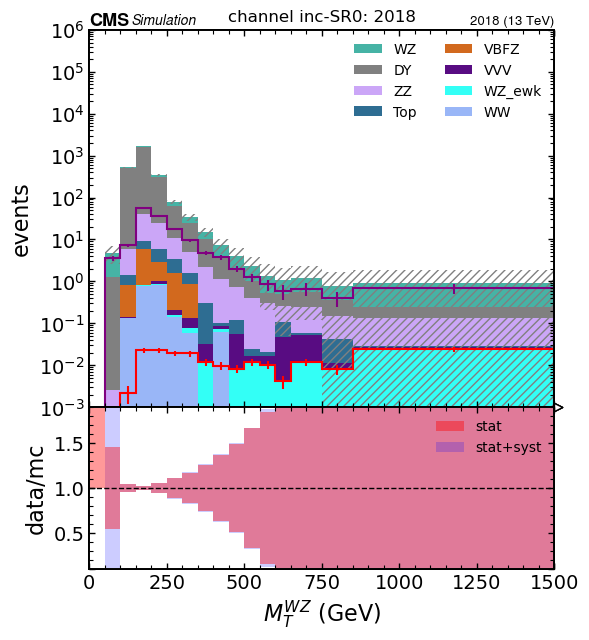

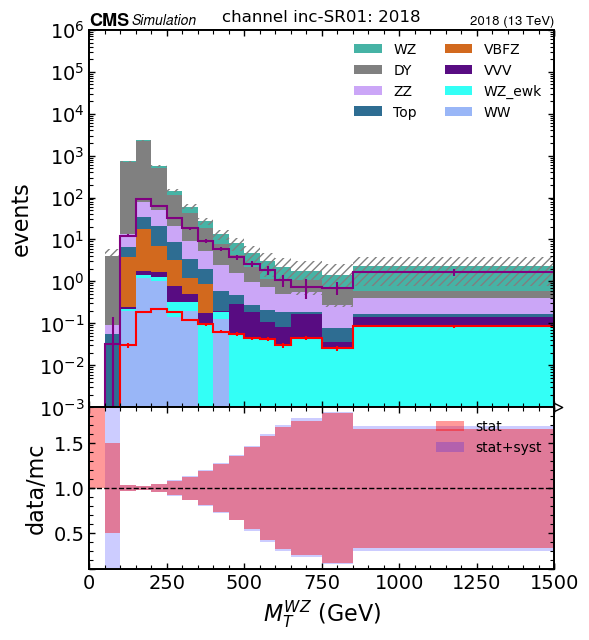

In [5]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-SR0"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=2.27506, variance=0.00118673)
DY =  WeightedSum(value=66688.7, variance=242200)
WW =  WeightedSum(value=35.9862, variance=2.27256)
ZZ =  WeightedSum(value=93.1435, variance=0.112881)
WZ =  WeightedSum(value=204.136, variance=19.4161)
Top =  WeightedSum(value=1513.73, variance=53.4075)
VVV =  WeightedSum(value=5.44742, variance=0.127908)
VBFZ =  WeightedSum(value=945.054, variance=331.952)


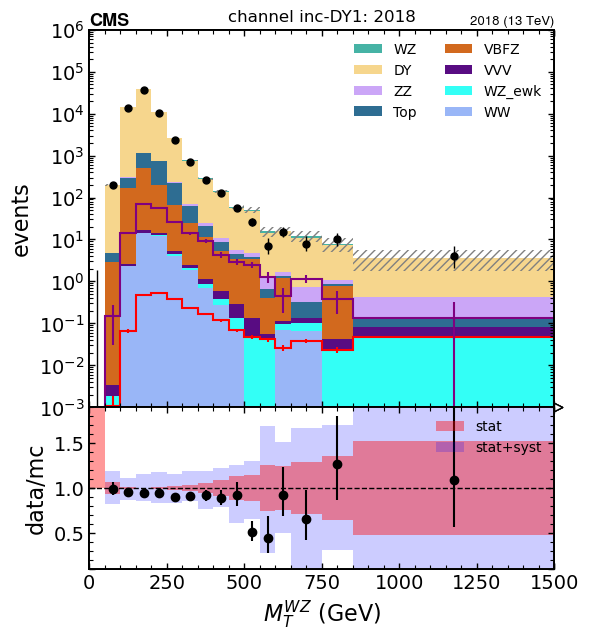

In [7]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-DY1"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'njets'
# rrt = "datadriven"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             # remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=1.52499, variance=0.000514057)
DY =  WeightedSum(value=46315.8, variance=117459)
WW =  WeightedSum(value=26.7995, variance=1.62168)
ZZ =  WeightedSum(value=65.0882, variance=0.0630834)
WZ =  WeightedSum(value=141.092, variance=9.1626)
Top =  WeightedSum(value=1057.51, variance=35.8262)
VVV =  WeightedSum(value=4.224, variance=0.102135)
VBFZ =  WeightedSum(value=634.613, variance=267.677)


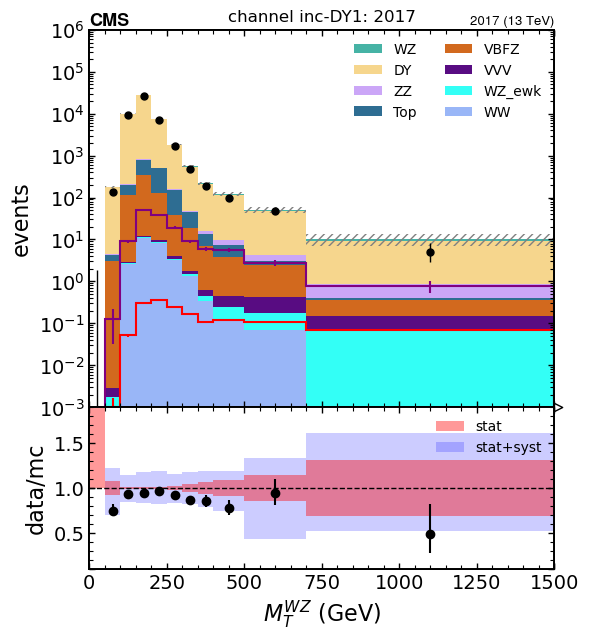

In [23]:
config_2017 = dctools.read_config("config/inc-WZ/input_UL_2017-WZ_inclusive.yaml")
y = "2017"
c = "inc-DY1"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2017.plotting:
    ch_cfg = config_2017.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2017, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2017",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=0.631205, variance=8.86052e-05)
DY =  WeightedSum(value=11977.8, variance=12705.5)
WW =  WeightedSum(value=9.43694, variance=0.53276)
ZZ =  WeightedSum(value=22.3226, variance=0.0176957)
WZ =  WeightedSum(value=53.7453, variance=1.31114)
Top =  WeightedSum(value=378.559, variance=11.9587)
VVV =  WeightedSum(value=1.40378, variance=0.000636702)
VBFZ =  WeightedSum(value=175.909, variance=36.2646)


/srv/DCTools/dctools/plot.py:291: RuntimeWarning: divide by zero encountered in divide
  np.divide(np.abs(shape_dw - pred_values), pred_values, where=shape_dw!=0)>10,


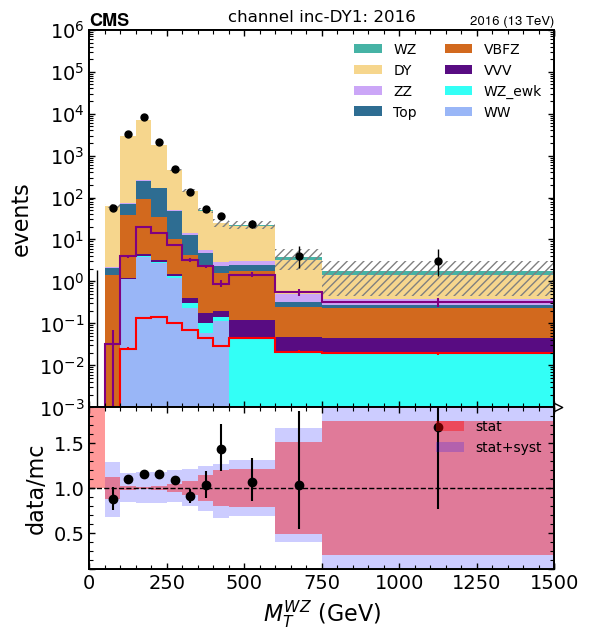

In [34]:
config_2016 = dctools.read_config("config/inc-WZ/input_UL_2016-WZ_inclusive.yaml")
y = "2016"
c = "inc-DY1"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2016.plotting:
    ch_cfg = config_2016.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2016, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2016",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=0.815892, variance=0.000136527)
DY =  WeightedSum(value=15563.3, variance=20397)
WW =  WeightedSum(value=10.1308, variance=0.695146)
ZZ =  WeightedSum(value=28.1721, variance=0.0284761)
WZ =  WeightedSum(value=67.561, variance=2.25786)
Top =  WeightedSum(value=502.406, variance=23.4575)
VVV =  WeightedSum(value=1.82993, variance=0.000926099)
VBFZ =  WeightedSum(value=232.506, variance=55.6596)


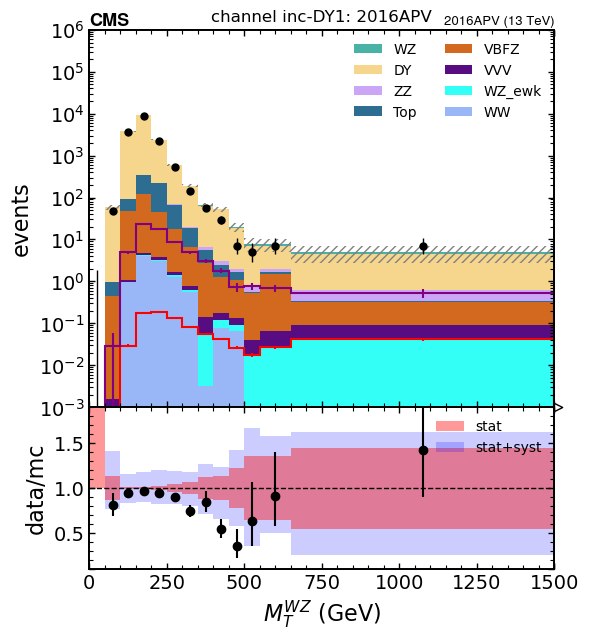

In [54]:
config_2016APV = dctools.read_config("config/inc-WZ/input_UL_2016APV-WZ_inclusive.yaml")
y = "2016APV"
c = "inc-DY1"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2016APV.plotting:
    ch_cfg = config_2016APV.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2016APV, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2016APV",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=0.397423, variance=0.000209628)
DY =  WeightedSum(value=152278, variance=427374)
WW =  WeightedSum(value=97.4103, variance=6.29)
ZZ =  WeightedSum(value=177.253, variance=0.223573)
WZ =  WeightedSum(value=285.244, variance=21.4443)
Top =  WeightedSum(value=421.969, variance=15.0235)
VVV =  WeightedSum(value=1.99829, variance=0.0412436)
VBFZ =  WeightedSum(value=373.818, variance=131.834)


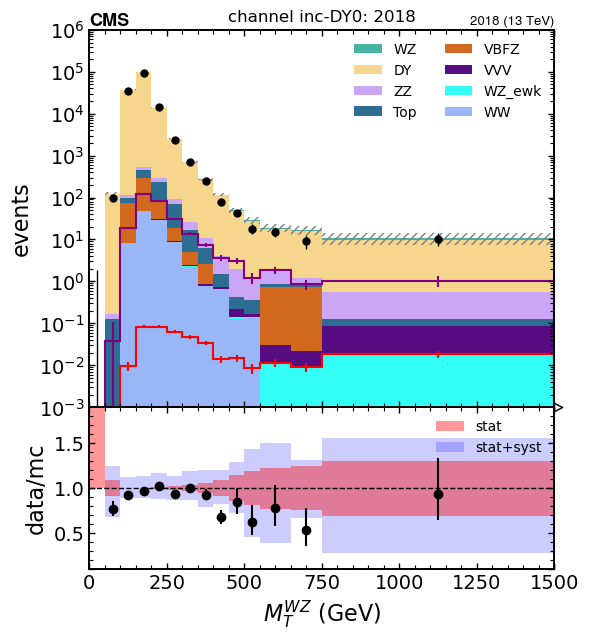

In [12]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-DY0"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'met_pt'
# rrt = "datadriven"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             # remap_replacement_types = rrt,
             # logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=2.27506, variance=0.00118673)
DY =  WeightedSum(value=66687.9, variance=242199)
WW =  WeightedSum(value=35.9857, variance=2.27256)
ZZ =  WeightedSum(value=93.1471, variance=0.112886)
WZ =  WeightedSum(value=204.136, variance=19.4161)
Top =  WeightedSum(value=1513.8, variance=53.4096)
VVV =  WeightedSum(value=5.44742, variance=0.127908)
VBFZ =  WeightedSum(value=945.054, variance=331.952)


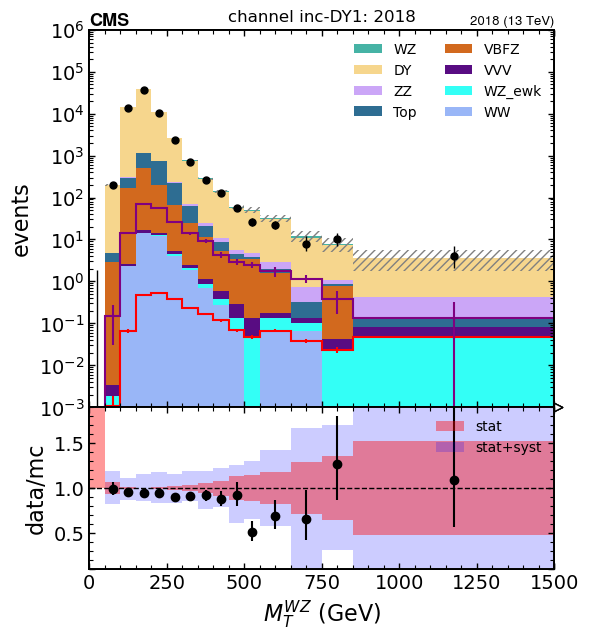

In [14]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-DY1"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'dilep_pt'
rrt = "datadriven"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

In [26]:
def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear", checksyst=True,
             remap_replacement_types = None, logy=True, logx=False, bin_width_norm=None, no_ratios=False,
             combine_fit="pre-combine", combine_total_uncertainty="total_background", combine_channel_group=None) -> None:
    assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]
    if remap_replacement_types is None:
        remap_replacement_types = [] #expected args: "datadriven", "validation"
    datasets:Dict = dict()
    color_cycle:List = []
    edges:Iterable[str] | Iterable[float] | None = None
    combine_uncertainty_histo: hist.Hist | None = None
    combine_channels: List[str] | None = None
    combine_lumi: int | None = None
    combine_era: str | None = None

    if bin_width_norm is None and "bin_width_norm" in config:
        bin_width_norm = config.bin_width_norm

    for ng, name in enumerate(config.groups):
            histograms = dict(
                filter(
                    lambda _n: _n[0] in config.groups[name].processes,
                    config.boosthist.items()
                )
            )
            p = dctools.datagroup(
                histograms       = histograms,
                ptype            = config.groups[name].type,
                observable       = variable,
                name             = name,
                xsections        = config.xsections,
                channel          = channel,
                luminosity       = config.luminosity.value,
                rebin            = rebin,
                remap_class_name = config.groups[name].remap_class_name if "remap_class_name" in config.groups[name] else None,
            )
           
            if p.remap_replace_group_name is not None:
                if p.remap_replace_type in remap_replacement_types:
                    print(f"Overwriting: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} replaced by {p.name}")
                    # overwrite a previously defined dataset in the dictionary. This requires the remap types to be after ALL MC in the config file (and still before the real data)
                    datasets[p.remap_replace_group_name] = p
                    if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
                        # must replace the previous color cycler...
                        index = list(datasets.keys()).index(p.remap_replace_group_name)
                        color_cycle[index] = config.groups[name].color
                else:
                    print(f"Skipping: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} would have been replaced by {p.name}")
                    # this process is ignored / not added to the stack
                    continue
            else:
                datasets[p.name] = p
                if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
                    color_cycle.append(config.groups[name].color)
            if p.ptype == "signal":
                signal = p.name
    _plot_channel = plotter.add_process_axis(datasets)
    variable_in_axes = variable if variable in _plot_channel.axes.name else ""
    pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'),:,:]
    data = _plot_channel[{'systematic':'nominal'}].project('process', variable_in_axes)[hist.loc('data'),:]
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('data'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('DY'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WW'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ZZ'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('Top'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VVV'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VBFZ'),:])
    # data = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('data'),:]
    WZ_ewk = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:]
    DY =  _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('DY'),:]
    WW =  _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WW'),:]
    ZZ =  _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ZZ'),:]
    WZ =  _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:]
    Top = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('Top'),:]
    VVV = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VVV'),:]
    VBFZ = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VBFZ'),:]

    data_vals = data.view()
    WZ_ewk_vals = WZ_ewk.view()
    WW_vals = WW.view()
    ZZ_vals = ZZ.view()
    WZ_vals = WZ.view()
    Top_vals = Top.view()
    VVV_vals = VVV.view()
    VBFZ_vals = VBFZ.view()
    
    # Now compute DY component
    
    data_DY_ch = data_vals - (WZ_ewk_vals + WW_vals + ZZ_vals + WZ_vals + Top_vals + VVV_vals + VBFZ_vals)
    
    print(data_DY_ch)
    
    plt.figure(figsize=(6, 4.9 if no_ratios else 7))
    ax, bx = plotter.mcplot(
        pred[{'systematic':'nominal'}].stack('process'),
        data=None if blind else data,
        syst=pred.stack('process'),
        colors = color_cycle,
        no_ratios=no_ratios,
        bin_width_norm=bin_width_norm,
        combine_fit=combine_fit,
        combine_uncertainty_histo=combine_uncertainty_histo[{'systematic':'nominal'}] if combine_uncertainty_histo else None,
        combine_histo_edges=edges,
    )
    
    ymax = np.max([10000]+[c.get_height() for c in ax.containers[0] if ~np.isnan(c.get_height())])
    ymin = np.min([0.001]+[c.get_height() for c in ax.containers[0] if ~np.isnan(c.get_height())])
    
    ax.set_ylim(0.001, 100*ymax)
    #changes made for grant proposal plots
    # ax.set_ylim(0.001, 1200)
    try:
        sig_ewk = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:]   
        sig_qcd = _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:]   
        sig_ewk.plot(ax=ax, histtype='step', color='red', binwnorm=bin_width_norm)
        sig_qcd.plot(ax=ax, histtype='step', color='purple', binwnorm=bin_width_norm)
    except:
        pass
    if bx is not None:
        bx.set_ylim([0.1, 1.9])
        if len(xlim) > 0:
            bx.set_xlim(xlim)
    elif len(xlim) > 0:
        ax.set_xlim(xlim)
    ax.set_title(f"channel {combine_channel_group or channel}: {combine_era or era}")
    # hep.cms.label("", ax=ax, data=not blind, lumi=combine_lumi, year=combine_era or int(era)) #add lumi=lumi, add year=int(era) with handling of APV, etc.
    hep.cms.label("", ax=ax, data=not blind, lumi=combine_lumi, year=era)
    
    if logy :
        ylim_orig = ax.get_ylim()
        if ylim_orig[0]<=0:
            ax.set_ylim(10^(-1), ylim_orig[1])
        ax.set_yscale('log')
    if logx :
        xlim_orig = ax.get_xlim()
        if xlim_orig[0]<=0:
            ax.set_xlim(10**(1.5), xlim_orig[1])
            # print(xlim_orig[1])
        ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_xlim(50,1500)
    # ax.set_xscale('log')

    # if checksyst:
    #     pred = _plot_channel.project('process','systematic', variable)[:hist.loc('data'),:,:]
    #     data = _plot_channel[{'systematic':'nominal'}].project('process',variable)[hist.loc('data'),:] 
    #     plotter.check_systematic(
    #         pred[{'systematic':'nominal'}].stack('process'),
    #         syst=pred.stack('process'),
    #         plot_file_name=f'check-sys-{channel}-{era}', 
    #         xrange=xlim,
    #         no_ratios=no_ratios,
    #         bin_width_norm=bin_width_norm,
    #     )
    #     plt.clf()
    return _plot_channel, datasets


        

WeightedSumView: (value, variance)
[( 0.00000000e+00, 0.00000000e+00) ( 0.00000000e+00, 0.00000000e+00)
 ( 1.49957562e+03, 1.52942812e+03) ( 6.53882185e+02, 6.73235067e+02)
 ( 2.53358068e+02, 2.61621883e+02) ( 1.44193228e+02, 1.50252879e+02)
 ( 8.74140415e+01, 9.07567887e+01) ( 6.25726509e+01, 6.56620851e+01)
 ( 3.19891927e+01, 3.46547852e+01) ( 1.33371890e+01, 1.41469660e+01)
 ( 9.79641600e+00, 1.00093756e+01) ( 6.97733041e+00, 7.00003018e+00)
 ( 6.94272668e+00, 7.00115999e+00) ( 2.90375070e+00, 3.00321531e+00)
 ( 1.96689667e+00, 2.00069610e+00) ( 9.87699827e-01, 1.00001400e+00)
 ( 3.95161878e+00, 4.00208211e+00) (-6.27522935e-03, 7.24537318e-06)
 ( 2.99735440e+00, 3.00000351e+00) ( 9.98642344e-01, 1.00000184e+00)
 (-2.43191924e-03, 2.97106784e-06) ( 0.00000000e+00, 0.00000000e+00)
 (-3.66771838e-01, 1.34521581e-01) (-4.29942700e-04, 1.84850726e-07)
 ( 0.00000000e+00, 0.00000000e+00) ( 0.00000000e+00, 0.00000000e+00)
 (-4.90864351e-04, 2.40947811e-07) ( 0.00000000e+00, 0.00000000e+00)

/srv/DCTools/dctools/plot.py:286: RuntimeWarning: divide by zero encountered in divide
  np.divide(np.abs(shape_up - pred_values), pred_values, where=shape_up!=0)>10,
/srv/DCTools/dctools/plot.py:291: RuntimeWarning: divide by zero encountered in divide
  np.divide(np.abs(shape_dw - pred_values), pred_values, where=shape_dw!=0)>10,


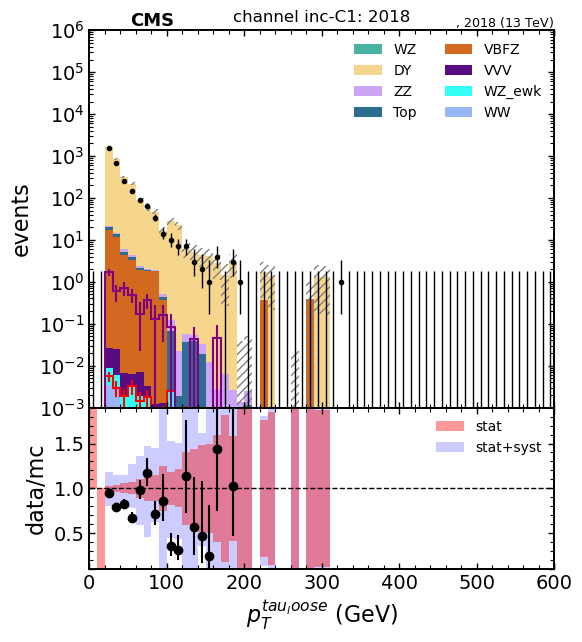

In [24]:
# from boost_histogram import histogram
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-C1"
# v = "dilep_tau_loose_met_hadron_mt"
v = 'tau_pt_loose'
# rrt = "validation"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             rebin = v_cfg.rebin,
             # xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             # remap_replacement_types = rrt,
             # logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

Skipping: channel: inc-D1 type: validation, DY would have been replaced by DDDY
WeightedSumView: (value, variance)
[(54.21619005, 56.16831414) (55.17213378, 56.01573481)
 (28.88806607, 31.25466647) (24.52230562, 26.16731038)
 (31.86938885, 35.2093122 ) (18.00366046, 19.01721155)
 ( 9.95289577, 11.14156206) ( 3.92928335,  5.1944223 )]


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


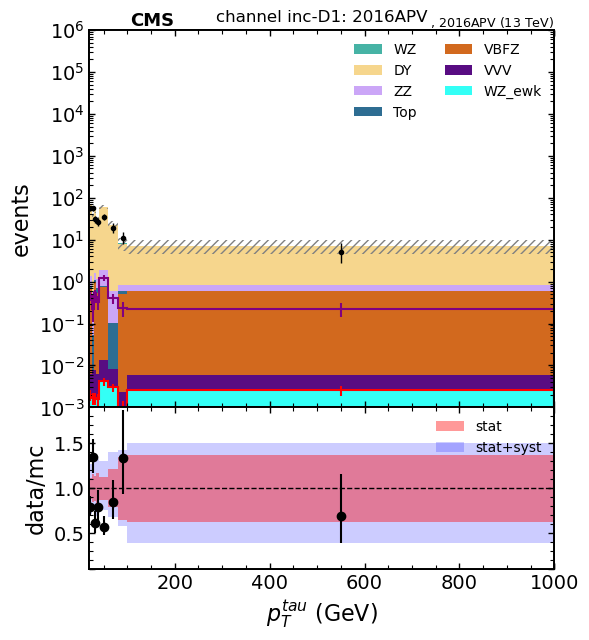

In [25]:
# from boost_histogram import histogram
config_2016APV = dctools.read_config("config/inc-WZ/input_UL_2016APV-WZ_inclusive.yaml")
y = "2016APV"
c = "inc-D1"
# v = "dilep_tau_loose_met_hadron_mt"
v = 'tau_pt'
# rrt = "validation"

for channel in config_2016APV.plotting:
    ch_cfg = config_2016APV.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2016APV, vname, channel,
             rebin = v_cfg.rebin,
             xlim = [],
             blind=v_cfg.blind,
             era = "2016APV",
             # remap_replacement_types = rrt,
             # logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

Overwriting: channel: inc-SR0 type: datadriven, DY replaced by DDDY
WZ_ewk =  WeightedSum(value=0.186567, variance=9.02343e-05)
DY =  WeightedSum(value=2485.77, variance=44.1297)
WW =  WeightedSum(value=2.01451, variance=0.13992)
ZZ =  WeightedSum(value=70.1002, variance=0.0748791)
WZ =  WeightedSum(value=144.794, variance=8.55967)
Top =  WeightedSum(value=10.0486, variance=0.326122)
VVV =  WeightedSum(value=0.492838, variance=0.0113861)
VBFZ =  WeightedSum(value=9.80189, variance=3.44368)


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


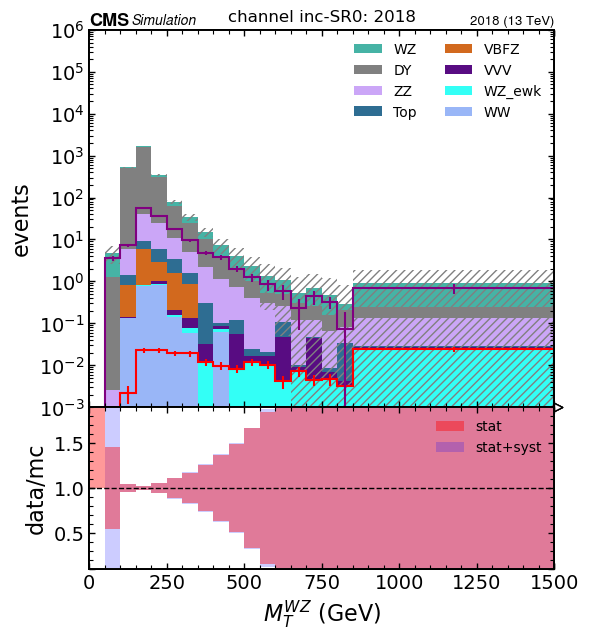

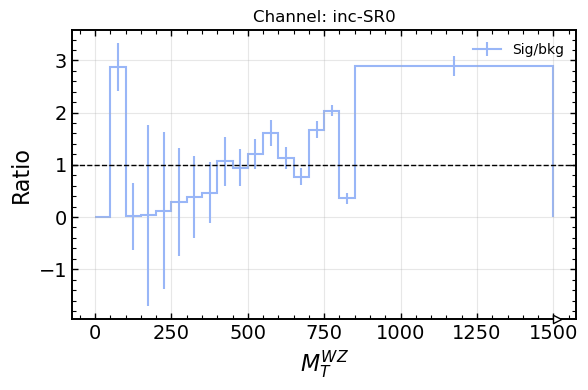

Overwriting: channel: inc-SR0 type: datadriven, DY replaced by DDDY


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


WZ_ewk =  WeightedSum(value=0.186567, variance=9.02343e-05)
DY =  WeightedSum(value=2485.77, variance=44.1297)
WW =  WeightedSum(value=2.01451, variance=0.13992)
ZZ =  WeightedSum(value=70.1002, variance=0.0748791)
WZ =  WeightedSum(value=144.794, variance=8.55967)
Top =  WeightedSum(value=10.0486, variance=0.326122)
VVV =  WeightedSum(value=0.492838, variance=0.0113861)
VBFZ =  WeightedSum(value=9.80189, variance=3.44368)


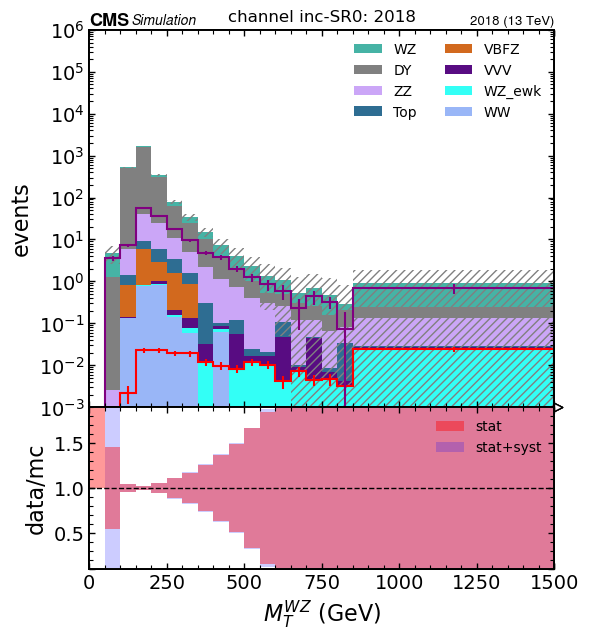

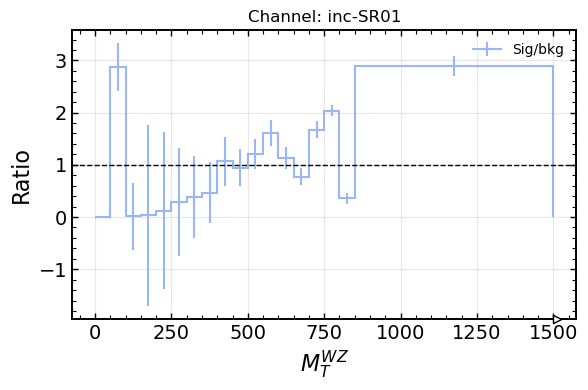

In [7]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-SR0"
v = "dilep_tau_loose_met_hadron_mt"
rrt = "datadriven"
for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        _plot_channel, datasets = plotting(
            config_2018, v, c,
            rebin=[5]*17+[65],
            xlim=[],
            blind=v_cfg.blind,
            era="2018",
            remap_replacement_types=rrt,
        )

        h = _plot_channel[{'systematic': 'nominal'}].project('process', vname)
        
        h_WZ     = h[hist.loc('WZ'), :]
        h_DY     = h[hist.loc('DY'), :]
        h_WW     = h[hist.loc('WW'), :]
        h_WZewk  = h[hist.loc('WZ_ewk'), :]
        h_ZZ     = h[hist.loc('ZZ'), :]
        h_VBFZ   = h[hist.loc('VBFZ'), :]
        h_Top   = h[hist.loc('Top'), :]
        h_VVV   = h[hist.loc('VVV'), :]

        h_bkg = h_DY + h_WW + h_WZewk + h_ZZ + h_VBFZ + h_Top + h_VVV
        
        def safe_ratio(num, den):
            den_vals = den.values()
            num_vals = num.values()
            mask = den_vals == 0
            ratio_vals = np.zeros_like(num_vals, dtype=float)
            ratio_vals[~mask] = num_vals[~mask] / den_vals[~mask]
            ratio = num.copy()
            ratio.values()[...] = ratio_vals
            return ratio
        
        r_WZ_bkg    = safe_ratio(h_WZ, h_bkg)
        
        # --- plot ---
        plt.figure(figsize=(6, 4))
        ax = plt.gca()
        
        r_WZ_bkg.plot(ax=ax, histtype='step', label='Sig/bkg')
    
        
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel('$M_T^{WZ}$')
        ax.set_ylabel('Ratio')
        # ax.set_ylim(0, 5)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # hep.cms.label("", ax=ax, year=2018)
        ax.set_title(f"Channel: {channel}")
        
        plt.tight_layout()
        plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import hist
import dctools
from dctools import plot as plotter
from dctools.plot import plotting

config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")


sig = "WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"
bkg = ['DYJetsToLL_0J_TuneCP5_13TeV-amcatnloFXFX-pythia8', 
       'DYJetsToLL_1J_TuneCP5_13TeV-amcatnloFXFX-pythia8', 
       'DYJetsToLL_2J_TuneCP5_13TeV-amcatnloFXFX-pythia8', 
       'GluGluToWWToENEN_TuneCP5_13TeV_MCFM701_pythia8', 
       'GluGluToWWToENMN_TuneCP5_13TeV_MCFM701_pythia8', 
       'GluGluToWWToENTN_TuneCP5_13TeV_MCFM701_pythia8', 
       'GluGluToWWToMNMN_TuneCP5_13TeV_MCFM701_pythia8',
       'GluGluToWWToMNEN_TuneCP5_13TeV_MCFM701_pythia8',
       'GluGluToWWToMNTN_TuneCP5_13TeV_MCFM701_pythia8',
       'WZZ_TuneCP5_13TeV-amcatnlo-pythia8', 
       'GluGluToWWToTNMN_TuneCP5_13TeV_MCFM701_pythia8',
       'GluGluToWWToTNTN_TuneCP5_13TeV_MCFM701_pythia8', 
       'GluGluToContinToZZTo2e2mu_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo2e2nu_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo2e2tau_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo2mu2nu_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo2mu2tau_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo4e_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo4mu_TuneCP5_13TeV-mcfm701-pythia8', 
       'GluGluToContinToZZTo4tau_TuneCP5_13TeV-mcfm701-pythia8',
       'ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8',
       'ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 
       'ST_tW_top_5f_NoFullyHadronicDecays_TuneCP5_13TeV-powheg-pythia8', 
       'ST_tW_antitop_5f_NoFullyHadronicDecays_TuneCP5_13TeV-powheg-pythia8',
       'ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8', 
       'ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 
       'ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 
       'tZq_ll_4f_ckm_NLO_TuneCP5_13TeV-amcatnlo-pythia8', 
       'TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8', 
       'TTWJetsToLNu_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8', 
       'TTWJetsToQQ_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8', 
       'TTZToLLNuNu_M-10_TuneCP5_13TeV-amcatnlo-pythia8', 
       'TTZToQQ_TuneCP5_13TeV-amcatnlo-pythia8', 
       'TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8', 
       'WWTo2L2Nu_TuneCP5_13TeV-powheg-pythia8', 
       'WZJJ_EWK_InclusivePolarization_TuneCP5_13TeV_madgraph-madspin-pythia8',
       'ZZTo2L2Nu_TuneCP5_13TeV_powheg_pythia8', 
       'ZZJJ_ZZTo2L2Nu_EWK_dipoleRecoil_TuneCP5_13TeV-madgraph-pythia8',
       'EWKZ2Jets_ZToLL_M-50_TuneCP5_withDipoleRecoil_13TeV-madgraph-pythia8', 
       'EWKWPlus2Jets_WToLNu_M-50_TuneCP5_withDipoleRecoil_13TeV-madgraph-pythia8', 
       'WWW_4F_TuneCP5_13TeV-amcatnlo-pythia8', 
       'EWKWMinus2Jets_WToLNu_M-50_TuneCP5_withDipoleRecoil_13TeV-madgraph-pythia8',
       'WWZ_4F_TuneCP5_13TeV-amcatnlo-pythia8', 
       'ZZZ_TuneCP5_13TeV-amcatnlo-pythia8', 
       'WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8', 
       'ZZTo4L_TuneCP5_13TeV_powheg_pythia8'
      ]
data = ['MuonEG', 'DoubleMuon', 'SingleMuon', 'EGamma']
h = config_2018.boosthist[sig]["hist"]["dilep_tau_loose_met_hadron_mt"]
h_DY = config_2018.boosthist['DYJetsToLL_0J_TuneCP5_13TeV-amcatnloFXFX-pythia8']["hist"]["dilep_tau_loose_met_hadron_mt"]
# print(h_DY[{"channel": "inc-SR0", "systematic": "nominal", "dilep_tau_loose_met_hadron_mt": hist.rebin(groups = [1]*30+[2]*10+[10]*10)}].sum())
h_bkg = None
h_data = None
for sample in bkg:
    h_tmp = (
        config_2018.boosthist[sample]["hist"]["dilep_tau_loose_met_hadron_mt"]
    )
    if h_bkg is None:
        h_bkg = h_tmp
    else:
        h_bkg = h_bkg + h_tmp

for sample in data:
    h_tmp = (
        config_2018.boosthist[sample]["hist"]["dilep_tau_loose_met_hadron_mt"]
    )
    if h_data is None:
        h_data = h_tmp
    else:
        h_data = h_data + h_tmp

# Projections
h_sig = h[{"channel": "inc-SR0", "systematic": "nominal", "dilep_tau_loose_met_hadron_mt": hist.rebin(1)}] #[1]*30+[2]*10+[10]*10
h_bkg = h_bkg[{"channel": "inc-SR0", "systematic": "nominal", "dilep_tau_loose_met_hadron_mt": hist.rebin(1)}]
h_data = h_data[{"channel": "inc-SR0", "systematic": "nominal", "dilep_tau_loose_met_hadron_mt": hist.rebin(1)}]
sig_vals = h_sig.values()
bkg_vals = h_bkg.values()
data_vals = h_data.values()
# print(bkg_vals)
# print(data_vals.sum())
# Bin centers for ratio plot
bin_edges = h_sig.axes["dilep_tau_loose_met_hadron_mt"].edges
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# # Ratios (safe division)
ratio = np.divide(sig_vals, bkg_vals, out=np.zeros_like(sig_vals), where=bkg_vals != 0)


# Figure with ratio panel
fig, (ax, rax) = plt.subplots(
    2, 1, figsize=(6, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# === Main plot ===
h_sig.plot(ax=ax, histtype="step", label="signal")
h_bkg.plot(ax=ax, histtype="step", label="background")


ax.set_ylabel("Events")
ax.set_yscale("log")
ax.set_title(r"$m_T^{WZ}$ for inc-SR0")
ax.legend()
ax.grid(True)

# === Ratio plot ===
rax.step(bin_centers, ratio, where="mid", label="Sig/Bkg", color="C1")
# rax.step(bin_centers, ratio_dn, where="mid", label="Down / Nom", color="C2")

# rax.axhline(1.0, color="black", linestyle="--", linewidth=1)
rax.set_ylabel("Ratio")
rax.set_xlabel(r"$m_T^{WZ}$ [GeV]")
# rax.set_ylim(-0.1, 2)
rax.legend()
rax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import hist
import dctools
from dctools import plot as plotter
from dctools.plot import plotting

config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
# print(config_2018.boosthist.keys())
h = config_2018.boosthist["WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"]["hist"]["dilep_tau_loose_met_hadron_mt"]
name = "WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"
h['inc-SR0', 'nominal', :].project("dilep_tau_loose_met_hadron_mt").plot1d()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import hist
import dctools
from dctools import plot as plotter
from dctools.plot import plotting

config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
print(config_2018.boosthist.keys())

sig = "WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"
bkg = ['DYJetsToLL_0J_TuneCP5_13TeV-amcatnloFXFX-pythia8', 'DYJetsToLL_1J_TuneCP5_13TeV-amcatnloFXFX-pythia8', 'DYJetsToLL_2J_TuneCP5_13TeV-amcatnloFXFX-pythia8', 'GluGluToWWToENEN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToWWToENMN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToWWToENTN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToWWToMNMN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToWWToMNEN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToWWToMNTN_TuneCP5_13TeV_MCFM701_pythia8', 'WZZ_TuneCP5_13TeV-amcatnlo-pythia8', 'GluGluToWWToTNMN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToWWToTNTN_TuneCP5_13TeV_MCFM701_pythia8', 'GluGluToContinToZZTo2e2mu_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo2e2nu_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo2e2tau_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo2mu2nu_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo2mu2tau_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo4e_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo4mu_TuneCP5_13TeV-mcfm701-pythia8', 'GluGluToContinToZZTo4tau_TuneCP5_13TeV-mcfm701-pythia8', 'ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 'ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 'ST_tW_top_5f_NoFullyHadronicDecays_TuneCP5_13TeV-powheg-pythia8', 'ST_tW_antitop_5f_NoFullyHadronicDecays_TuneCP5_13TeV-powheg-pythia8', 'ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8', 'ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 'ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 'tZq_ll_4f_ckm_NLO_TuneCP5_13TeV-amcatnlo-pythia8', 'TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8', 'TTWJetsToLNu_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8', 'TTWJetsToQQ_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8', 'TTZToLLNuNu_M-10_TuneCP5_13TeV-amcatnlo-pythia8', 'TTZToQQ_TuneCP5_13TeV-amcatnlo-pythia8', 'TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8', 'WWTo2L2Nu_TuneCP5_13TeV-powheg-pythia8', 'WZJJ_EWK_InclusivePolarization_TuneCP5_13TeV_madgraph-madspin-pythia8', 'ZZTo2L2Nu_TuneCP5_13TeV_powheg_pythia8', 'ZZJJ_ZZTo2L2Nu_EWK_dipoleRecoil_TuneCP5_13TeV-madgraph-pythia8', 'EWKZ2Jets_ZToLL_M-50_TuneCP5_withDipoleRecoil_13TeV-madgraph-pythia8', 'EWKWPlus2Jets_WToLNu_M-50_TuneCP5_withDipoleRecoil_13TeV-madgraph-pythia8', 'WWW_4F_TuneCP5_13TeV-amcatnlo-pythia8', 'EWKWMinus2Jets_WToLNu_M-50_TuneCP5_withDipoleRecoil_13TeV-madgraph-pythia8', 'WWZ_4F_TuneCP5_13TeV-amcatnlo-pythia8', 'ZZZ_TuneCP5_13TeV-amcatnlo-pythia8', 'WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8', 'ZZTo4L_TuneCP5_13TeV_powheg_pythia8']
h = config_2018.boosthist[sig]["hist"]["dilep_tau_loose_met_hadron_mt"]
h_bkg = None

for sample in bkg:
    h_tmp = (
        config_2018.boosthist[sample]["hist"]["dilep_tau_loose_met_hadron_mt"]
    )
    if h_bkg is None:
        h_bkg = h_tmp
    else:
        h_bkg = h_bkg + h_tmp

# Projections
h_sig = h[{"channel": "inc-SR0", "systematic": "nominal", "dilep_tau_loose_met_hadron_mt": hist.rebin(groups = [5]*10+[20]*3+[40])}]
h_bkg = h_bkg[{"channel": "inc-SR0", "systematic": "nominal", "dilep_tau_loose_met_hadron_mt": hist.rebin(groups = [5]*10+[20]*3+[40])}]
sig_vals = h_sig.values()
bkg_vals = h_bkg.values()

# Bin centers for ratio plot
bin_edges = h_sig.axes["dilep_tau_loose_met_hadron_mt"].edges
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# # Ratios (safe division)
ratio = np.divide(sig_vals, bkg_vals, out=np.zeros_like(sig_vals), where=bkg_vals != 0)


# Figure with ratio panel
fig, (ax, rax) = plt.subplots(
    2, 1, figsize=(6, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# === Main plot ===
h_sig.plot(ax=ax, histtype="step", label="signal")
h_bkg.plot(ax=ax, histtype="step", label="background")


ax.set_ylabel("Events")
ax.set_yscale("log")
ax.set_title(r"$m_T^{WZ}$ for inc-SR0")
ax.legend()
ax.grid(True)

# === Ratio plot ===
rax.step(bin_centers, ratio, where="mid", label="Sig/Bkg", color="C1")
# rax.step(bin_centers, ratio_dn, where="mid", label="Down / Nom", color="C2")

# rax.axhline(1.0, color="black", linestyle="--", linewidth=1)
rax.set_ylabel("Ratio")
rax.set_xlabel(r"$m_T^{WZ}$ [GeV]")
rax.set_ylim(-0.1, 2)
rax.legend()
rax.grid(True)

plt.tight_layout()
plt.show()


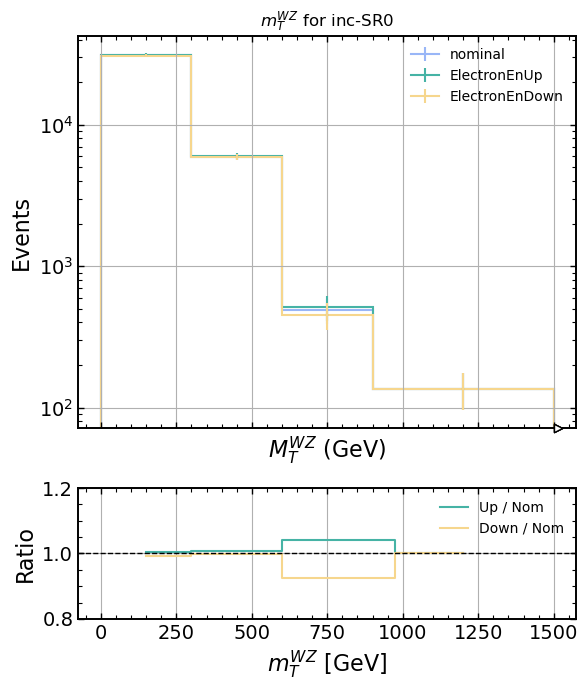

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import hist
import dctools
from dctools import plot as plotter
from dctools.plot import plotting

config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")


name = "WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"
h = config_2018.boosthist[name]["hist"]["dilep_tau_loose_met_hadron_mt"]

s = ["nominal", "ElectronEnUp", "ElectronEnDown"]


# Projections
h_nom = h[{"channel": "inc-SR0", "systematic": s[0], "dilep_tau_loose_met_hadron_mt": hist.rebin(groups=[30]*3+[60])}]
h_up  = h[{"channel": "inc-SR0", "systematic": s[1], "dilep_tau_loose_met_hadron_mt": hist.rebin(groups=[30]*3+[60])}]
h_dn  = h[{"channel": "inc-SR0", "systematic": s[2], "dilep_tau_loose_met_hadron_mt": hist.rebin(groups=[30]*3+[60])}]

nom_vals = h_nom.values()
up_vals  = h_up.values()
dn_vals  = h_dn.values()

# Bin centers for ratio plot
bin_edges = h_nom.axes["dilep_tau_loose_met_hadron_mt"].edges
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Ratios (safe division)
ratio_up = np.divide(up_vals, nom_vals, out=np.zeros_like(up_vals), where=nom_vals != 0)
ratio_dn = np.divide(dn_vals, nom_vals, out=np.zeros_like(dn_vals), where=nom_vals != 0)

# Figure with ratio panel
fig, (ax, rax) = plt.subplots(
    2, 1, figsize=(6, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# === Main plot ===
h_nom.plot(ax=ax, histtype="step", label=s[0])
h_up.plot(ax=ax, histtype="step", label=s[1])
h_dn.plot(ax=ax, histtype="step", label=s[2])

ax.set_ylabel("Events")
ax.set_yscale("log")
ax.set_title(r"$m_T^{WZ}$ for inc-SR0")
ax.legend()
ax.grid(True)

# === Ratio plot ===
rax.step(bin_centers, ratio_up, where="mid", label="Up / Nom", color="C1")
rax.step(bin_centers, ratio_dn, where="mid", label="Down / Nom", color="C2")

rax.axhline(1.0, color="black", linestyle="--", linewidth=1)
rax.set_ylabel("Ratio")
rax.set_xlabel(r"$m_T^{WZ}$ [GeV]")
rax.set_ylim(0.8, 1.2)
rax.legend()
rax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import hist

name = "WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"
h = config_2018.boosthist[name]["hist"]["mT_WZ"]

# Choose the systematics you want
systematics = ["nominal", "JERUp", "JERDown"]

# Create figure
plt.figure(figsize=(6, 5))

for s in systematics:
    h_proj = h[{
        "channel": "inc-SR0",
        "systematic": s,
        "mT_WZ": hist.rebin(groups=[2]*20+[5]*4)
    }]
    h_proj.plot(histtype='step', label=s)

plt.xlabel(r"$mT\_{WZ}$ [GeV]")
plt.ylabel("Events")
plt.title("m_T for inc-SR0: Nominal vs JERUp")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale("log")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import hist

name = "WZTo3LNu_TuneCP5_13TeV-amcatnloFXFX-pythia8"
h = config_2018.boosthist[name]["hist"]["mT_WZ"]

# Choose the systematics you want
systematics = ["nominal", "QCDScale0wUp", "QCDScale0wDown"]

# Create figure
plt.figure(figsize=(6, 5))

for s in systematics:
    h_proj = h[{
        "channel": "inc-DY1",
        "systematic": s,
        "mT_WZ": hist.rebin(groups=[1]*30+[2]*5+[10]*2)
    }]
    h_proj.plot(histtype='step', label=s)

plt.xlabel(r"$mT\_WZ$ [GeV]")
plt.ylabel("Events")
plt.title("mT_WZ for inc-DY1: Nominal vs QCDScale0w")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
datasets:Dict = dict()
color_cycle:List = []
config =config_2018
a = []
for name in config.groups:
    histograms = dict(
        filter(
            lambda n: n[0] in config.groups[name].processes,
            config.boosthist.items()
            
        )
    )
    a.append(histograms)    
    
  #  p = dctools.datagroup(
   #     histograms = histograms,
    #    ptype      = config.groups[name].type,
     #   observable = 'tau_pt',
      #  name       = name,
       # xsections  = config.xsections,
        #channel    = 'vbs-Faketau_C',
        #luminosity = config.luminosity.value,
        #rebin      = 1
    #)
    #print(name)   
    #datasets[p.name] = p
    #if p.ptype == "Signal":
        #signal = p.name

#print(datasets)
#_plot_channel = plotter.add_process_axis(datasets)

#print(a)

In [1]:
import argparse
import gzip
import pickle
import matplotlib.pyplot as plt
import yaml
import io
import os
import numpy as np
import hist
from typing import Any, IO, Dict, List, Iterable
import dctools
from dctools import plot as plotter
from dctools.plot import plotting
import matplotlib.pyplot as plt
import scipy.interpolate as interp
import mplhep as hep
# hep.style.use('CMS')
from scipy import stats as st
np.seterr(all='warn')
plt.ioff()
from dctools import dict_to_hist_axis


In [2]:
def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear", checksyst=True,
             remap_replacement_types = None, logy=True, logx=False, bin_width_norm=None, no_ratios=False,
             combine_fit="pre-combine", combine_total_uncertainty="total_background", combine_channel_group=None) -> None:
    assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]
    if remap_replacement_types is None:
        remap_replacement_types = [] #expected args: "datadriven", "validation"
    datasets:Dict = dict()
    color_cycle:List = []
    edges:Iterable[str] | Iterable[float] | None = None
    combine_uncertainty_histo: hist.Hist | None = None
    combine_channels: List[str] | None = None
    combine_lumi: int | None = None
    combine_era: str | None = None

    if bin_width_norm is None and "bin_width_norm" in config:
        bin_width_norm = config.bin_width_norm

    for ng, name in enumerate(config.groups):
            histograms = dict(
                filter(
                    lambda _n: _n[0] in config.groups[name].processes,
                    config.boosthist.items()
                )
            )
            p = dctools.datagroup(
                histograms       = histograms,
                ptype            = config.groups[name].type,
                observable       = variable,
                name             = name,
                xsections        = config.xsections,
                channel          = channel,
                luminosity       = config.luminosity.value,
                rebin            = rebin,
                remap_class_name = config.groups[name].remap_class_name if "remap_class_name" in config.groups[name] else None,
            )
           
            if p.remap_replace_group_name is not None:
                if p.remap_replace_type in remap_replacement_types:
                    print(f"Overwriting: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} replaced by {p.name}")
                    # overwrite a previously defined dataset in the dictionary. This requires the remap types to be after ALL MC in the config file (and still before the real data)
                    datasets[p.remap_replace_group_name] = p
                    if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
                        # must replace the previous color cycler...
                        index = list(datasets.keys()).index(p.remap_replace_group_name)
                        color_cycle[index] = config.groups[name].color
                else:
                    print(f"Skipping: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} would have been replaced by {p.name}")
                    # this process is ignored / not added to the stack
                    continue
            else:
                datasets[p.name] = p
                if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
                    color_cycle.append(config.groups[name].color)
            if p.ptype == "signal":
                signal = p.name
    _plot_channel = plotter.add_process_axis(datasets)
    if variable not in _plot_channel.axes.name:
        raise ValueError(f"{variable} not found in histogram axes")

    variable_in_axes = variable
    pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'),:,:]
    data = _plot_channel[{'systematic':'nominal'}].project('process', variable_in_axes)[hist.loc('data'),:]
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('data'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('DY'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WW'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ZZ'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('Top'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VVV'),:])
    # print(_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VBFZ'),:])
    print("data = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('data'),:].sum())
    print("WZ_ewk = " ,_plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ_ewk'),:].sum())
    print("DY = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('DY'),:].sum())
    print("WW = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WW'),:].sum())
    print("ZZ = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ZZ'),:].sum())
    print("WZ = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('WZ'),:].sum())
    print("Top = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('Top'),:].sum())
    print("VVV = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VVV'),:].sum())
    # print("ggVV = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('ggVV'),:].sum())
    print("VBFZ = ", _plot_channel[{'systematic':'nominal'}].project('process', variable)[hist.loc('VBFZ'),:].sum())
    
    fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=False,)
    
    process_labels = {
    "WW": r"$WW \to \ell\nu\ell\nu$",
    "WZ_ewk": r"$WZ$ (EW production)",
    "VVV": r"Triboson",
    "VBFZ": r"$Z$ (VBF)",
    "Top": r"$t\bar{t}$ + single $t$",
    "ZZ": r"$ZZ$",
    "DY": r"$Z/\gamma^*$",
    "WZ": r"$WZ$ (QCD production)",}
    #Petroff-10 color scheme
    #["#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6", "#a96b59", "#e76300", "#b9ac70", "#717581", "#92dadd"]

    cms_colors = {
    "DY":      "#ffa90e",  
    "ZZ":      "#bd1f01",  
    "WZ":      "#3f90da",  
    "WZ_ewk":  "#b9ac70",  
    "WW":      "#e76300",  
    "Top":     "#94a4a2",  
    "VVV":     "#a96b59",  
    "VBFZ":    "#832db6",  
    }

    proc_axis = pred.axes['process']
    
    blind = v_cfg.blind
    # bkg_nominal_noDY = sum(pred[{'systematic': 'nominal', 'process': ['WW', 'WZ_ewk', 'VVV', 'VBFZ', 'Top', 'ZZ', 'WZ']}])
    # dy_ues_up = pred[{'systematic': 'UESUp', 'process': 'DY'}]
    # dy_ues_down = pred[{'systematic': 'UESDown', 'process': 'DY'}]
    signal_qcd = pred[{'systematic': 'nominal', 'process': 'WZ'}]
    signal_ewk = pred[{'systematic': 'nominal', 'process': 'WZ_ewk'}]
    # print(_plot_channel[{'systematic':'datadriven_DDDYNominalUp'}].project('process', variable)[hist.loc('data'),:])
    # print (datadriven_DDDYNominalUp)

    # model = sum(pred[{'systematic':'nominal'}].stack('process'))

    hep.comp.data_model(
        data_hist=data.copy().reset() if blind else data,
        stacked_components=pred[{'systematic':'nominal'}].stack('process'),
        stacked_labels = [process_labels[p] for p in proc_axis],
        stacked_colors = [cms_colors[p] for p in proc_axis],
        unstacked_components = [signal_qcd],
        unstacked_labels=["WZ_qcd"],
        unstacked_colors=["blue"],
        unstacked_kwargs_list=[{"linestyle": "dotted"},],
        model_sum_kwargs={"show": False},
        xlabel="",
        # blind=(40.0, 300.0),
        ylabel="Events",
        comparison="split_ratio",
        data_label='Data',
        model_uncertainty_label = "MC stat. unc.",
        fig=fig,
        ax_main=axes[0],
        ax_comparison=axes[1],
    )
    
    axes[0].set_yscale("log")
    axes[0].legend(ncol=2, fontsize=8, loc='upper right')
    # axes[1].set_xlabel("$M_{T}^{WZ}$")
    axes[1].set_ylim(0, 2)
    axes[0].set_xlim(xlim)
    axes[0].set_title(title, loc="center")
    axes[1].set_xlim(xlim)
    axes[1].set_xlabel(variable)

    combine_lumi = config.luminosity.value
    hep.cms.label(f"Preliminary — {c}", ax=axes[0], data=not blind, lumi=combine_lumi, year=combine_era or era)
    

    return _plot_channel, datasets
        

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


data =  WeightedSum(value=26678, variance=26678)
WZ_ewk =  WeightedSum(value=0.0714569, variance=3.42822e-05)
DY =  WeightedSum(value=30258.8, variance=85891.3)
WW =  WeightedSum(value=8.13404, variance=0.520883)
ZZ =  WeightedSum(value=42.6337, variance=0.0471877)
WZ =  WeightedSum(value=72.7971, variance=4.17396)
Top =  WeightedSum(value=31.1819, variance=1.0991)
VVV =  WeightedSum(value=0.257464, variance=0.00776445)
VBFZ =  WeightedSum(value=72.8651, variance=26.0159)


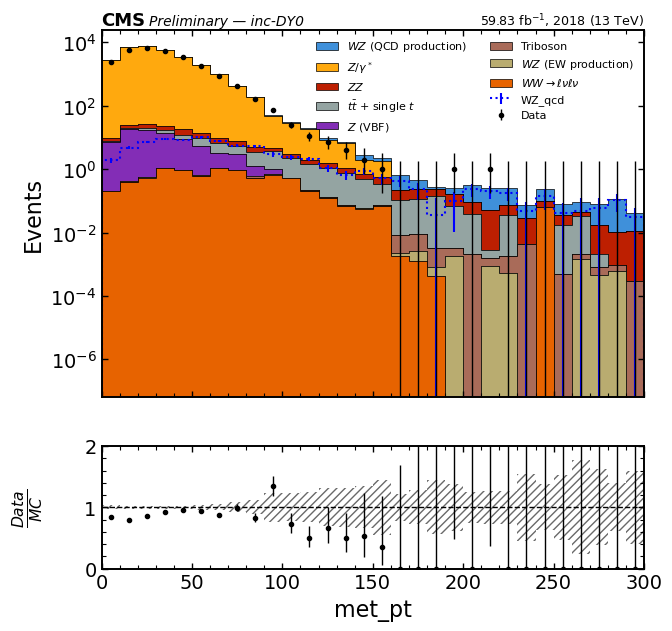

In [49]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
# print(config_2018.boosthist[name]["hist"]["dilep_tau_loose_met_hadron_mt"])
# print(config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"])
y = "2018"
c = "inc-DY0"
# v = "dilep_tau_loose_met_hadron_mt"
v = "met_pt"
rrt = "datadriven"
title = " "

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             # rebin = v_cfg.rebin,
             # rebin = [16, 4, 5, 5, 10, 10, 100], #fix for SR0
             # rebin = [16, 2, 2, 3, 10, 12, 20, 20, 25, 40], #fix for SR1
             xlim = v_cfg.range,
             rebin = 1,
             # xlim = (30,100),
             blind=v_cfg.blind,
             era = "2018",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


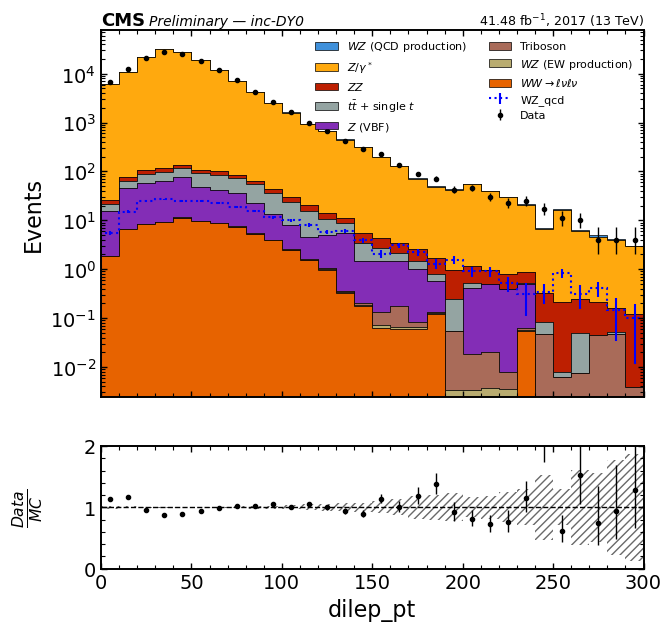

In [69]:
config_2017 = dctools.read_config("config/inc-WZ/input_UL_2017-WZ_inclusive.yaml")
# print(config_2018.boosthist[name]["hist"]["dilep_tau_loose_met_hadron_mt"])
# print(config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"])
y = "2017"
c = "inc-DY0"
# v = "dilep_tau_loose_met_hadron_mt"
v = "dilep_pt"
rrt = "datadriven"
title = " "

for channel in config_2017.plotting:
    ch_cfg = config_2017.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2017, vname, channel,
             # rebin = v_cfg.rebin,
             # rebin = [16, 4, 5, 5, 10, 10, 100], #fix for SR0
             # rebin = [16, 2, 2, 3, 10, 12, 20, 20, 25, 40], #fix for SR1
             xlim = v_cfg.range,
             rebin = 1,
             # xlim = (30,100),
             blind=v_cfg.blind,
             era = "2017",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

In [ ]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
# print(config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"])
# h = config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"]
# v = "dilep_m"
v = "dilep_tau_loose_met_hadron_mt"
h = (
    config_2018.boosthist['DoubleMuon']["hist"][v]
    + config_2018.boosthist['MuonEG']["hist"][v]
    + config_2018.boosthist['SingleMuon']["hist"][v]
    + config_2018.boosthist['EGamma']["hist"][v]
)
h_sel = h[{"channel": "inc-VB0", "systematic": "datadriven_DDDYNominalUp"}]
print(h_sel)
print(h_sel.sum())

# values = h_sel.values()
# edges = h_sel.axes["dilep_m"].edges
# centers = 0.5 * (edges[1:] + edges[:-1])

# plt.step(centers, values, where="mid")
# plt.xlabel(r"$M_{\ell\ell}$ (GeV)")
# plt.ylabel("Events")
# plt.title("DoubleMuon - inc-VB0")
# plt.show()

In [31]:
# def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear", checksyst=True,
#              remap_replacement_types = None, logy=True, logx=False, bin_width_norm=None, no_ratios=False,
#              combine_fit="pre-combine", combine_total_uncertainty="total_background", combine_channel_group=None) -> None:
#     assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]
#     if remap_replacement_types is None:
#         remap_replacement_types = [] #expected args: "datadriven", "validation"
#     datasets:Dict = dict()
#     color_cycle:List = []
#     edges:Iterable[str] | Iterable[float] | None = None
#     combine_uncertainty_histo: hist.Hist | None = None
#     combine_channels: List[str] | None = None
#     combine_lumi: int | None = None
#     combine_era: str | None = None

#     if bin_width_norm is None and "bin_width_norm" in config:
#         bin_width_norm = config.bin_width_norm

#     for ng, name in enumerate(config.groups):
#             histograms = dict(
#                 filter(
#                     lambda _n: _n[0] in config.groups[name].processes,
#                     config.boosthist.items()
#                 )
#             )
#             p = dctools.datagroup(
#                 histograms       = histograms,
#                 ptype            = config.groups[name].type,
#                 observable       = variable,
#                 name             = name,
#                 xsections        = config.xsections,
#                 channel          = channel,
#                 luminosity       = config.luminosity.value,
#                 rebin            = rebin,
#                 remap_class_name = config.groups[name].remap_class_name if "remap_class_name" in config.groups[name] else None,
#             )
           
#             if p.remap_replace_group_name is not None:
#                 if p.remap_replace_type in remap_replacement_types:
#                     print(f"Overwriting: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} replaced by {p.name}")
#                     # overwrite a previously defined dataset in the dictionary. This requires the remap types to be after ALL MC in the config file (and still before the real data)
#                     datasets[p.remap_replace_group_name] = p
#                     if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
#                         # must replace the previous color cycler...
#                         index = list(datasets.keys()).index(p.remap_replace_group_name)
#                         color_cycle[index] = config.groups[name].color
#                 else:
#                     print(f"Skipping: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} would have been replaced by {p.name}")
#                     # this process is ignored / not added to the stack
#                     continue
#             else:
#                 datasets[p.name] = p
#                 if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
#                     color_cycle.append(config.groups[name].color)
#             if p.ptype == "signal":
#                 signal = p.name
#     _plot_channel = plotter.add_process_axis(datasets)
#     variable_in_axes = variable if variable in _plot_channel.axes.name else ""
#     pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'),:,:]
#     data = _plot_channel[{'systematic':'nominal'}].project('process', variable_in_axes)[hist.loc('data'),:]
    
#     fig, axes = hep.subplots(nrows=6, hspace=0.3)
#     process_labels = {
#     "WW": r"$WW \to \ell\nu\ell\nu$",
#     "WZ_ewk": r"$WZ$ (EW production)",
#     "VVV": r"Triboson",
#     "VBFZ": r"$Z$ (VBF)",
#     "Top": r"$t\bar{t}$ + single $t$",
#     "ZZ": r"$ZZ$",
#     "DY": r"$Z/\gamma^*$",
#     "WZ": r"$WZ$ (QCD production)",}

#     cms_colors = {
#     "DY":      "#f9d35a",  # yellow
#     "ZZ":      "#4c72b0",  # blue
#     "WZ":      "#55a868",  # green
#     "WZ_ewk":  "#8172b2",  # purple
#     "WW":      "#64b5cd",  # light blue
#     "Top":     "#c44e52",  # red
#     "VVV":     "#dd8452",  # orange
#     "VBFZ":    "#937860",  # brown 
#     }

#     proc_axis = pred.axes['process']
    
#     blind = v_cfg.blind
#     bkg_nominal_noDY = sum(pred[{'systematic': 'nominal', 'process': ['WW', 'WZ_ewk', 'VVV', 'VBFZ', 'Top', 'ZZ', 'WZ']}])
#     dy_ues_up = pred[{'systematic': 'UESUp', 'process': 'DY'}]
#     dy_ues_down = pred[{'systematic': 'UESDown', 'process': 'DY'}]

#     hep.comp.data_model(
        
#         data_hist=data.copy().reset() if blind else data,
#         # data_hist = sum(pred[{'systematic':'UESUp'}].stack('process')),
#         stacked_components=pred[{'systematic':'nominal'}].stack('process'),
#         # stacked_labels=process_labels,
#         # # stacked_colors=plt.get_cmap("tab20").colors[:len(pred.axes['process'])],
#         # stacked_colors = [cms_colors[p] for p in process_labels],
#         stacked_labels = [process_labels[p] for p in proc_axis],
#         stacked_colors = [cms_colors[p] for p in proc_axis],
#         unstacked_components = [bkg_nominal_noDY + dy_ues_up, bkg_nominal_noDY + dy_ues_down],
#         # unstacked_components=[pred[{'systematic': 'nominal', 'process': 'WW'}]],
#         unstacked_labels=["UES Up", "UES Down"],
#         unstacked_colors=["black", "blue"],
#         unstacked_kwargs_list=[{"linestyle": "dotted"}, {"linestyle": "dashed"},],
#         xlabel="",
#         ylabel="Events",
#         comparison="ratio",
#         fig=fig,
#         ax_main=axes[0],
#         ax_comparison=axes[1],
#     )
#     # hep.add_text(c, ax=axes[0], loc="over left", fontsize="small",)
#     hep.add_text(r'  $\mathbf{→}$ comparison = "ratio"', ax=axes[1], loc="over left", fontsize=13)
#     axes[0].set_yscale("log")
#     combine_lumi = config.luminosity.value
#     hep.cms.label("Preliminary", ax=axes[0], data=not blind, lumi=combine_lumi, year=combine_era or era)

#     for k, comp in enumerate(["split_ratio", "pull", "relative_difference", "difference"], start=2):
#         hep.comp.comparison(
#             # data,
#             sum(pred[{'systematic':'nominal'}].stack('process')),
#             # sum(pred[{'systematic':'UESUp'}].stack('process')),
#             # sum(pred[{'systematic':'nominal'}].stack('process')),
#             bkg_nominal_noDY + dy_ues_down,
#             ax=axes[k],
#             comparison=comp,
#             xlabel="",
#             h1_label="UES",
#             h2_label="MC",
#             h1_w2method="poisson",
#         )
#         hep.add_text(
#             rf'  $\mathbf{{→}}$ comparison = "{comp}"',
#             ax=axes[k],
#             fontsize=13,
#             loc="over left",
#         )
#         hep.set_fitting_ylabel_fontsize(axes[k])

#     axes[-1].set_xlabel(variable)

#     return _plot_channel, datasets

# # 
        

Overwriting: channel: inc-SR0 type: datadriven, DY replaced by DDDY


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()
/srv/.env/lib/python3.12/site-packages/hist/basehist.py:549: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


Overwriting: channel: inc-SR01 type: datadriven, DY replaced by DDDY


/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()
/srv/.env/lib/python3.12/site-packages/hist/basehist.py:549: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


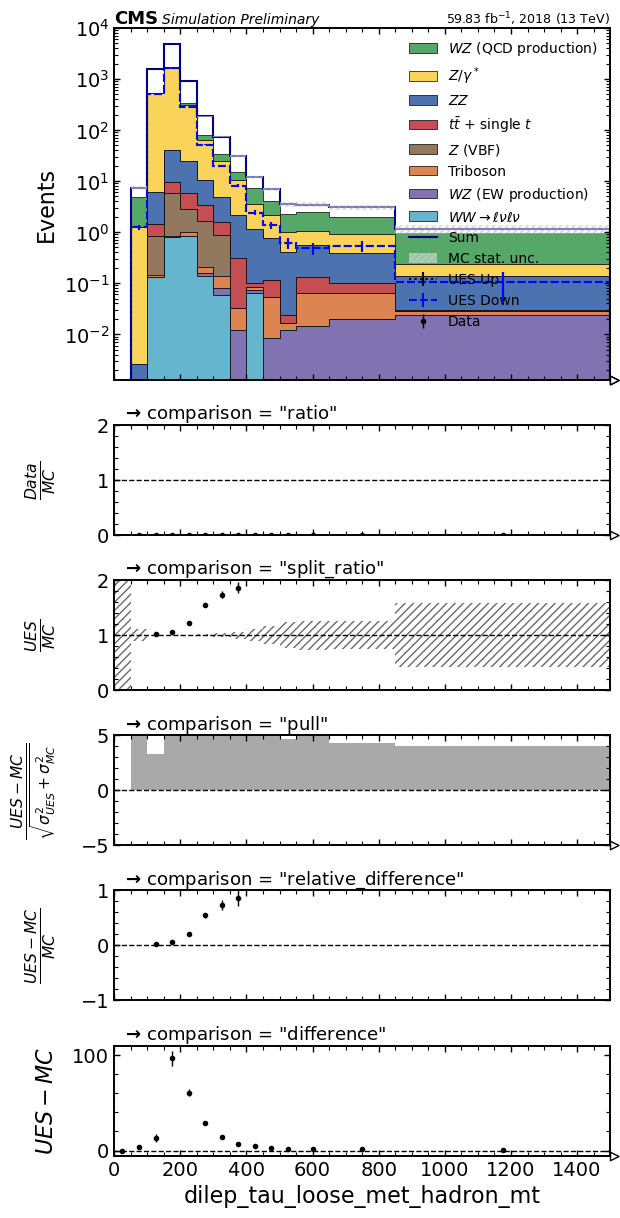

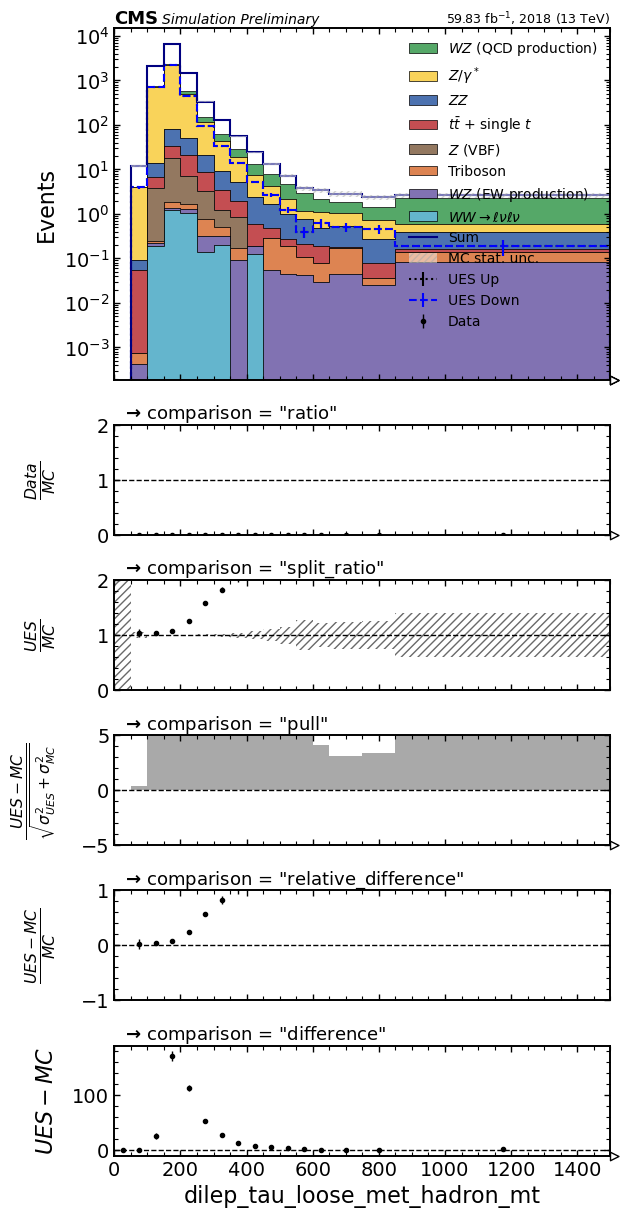

In [7]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-SR0"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             rebin = v_cfg.rebin,
             # rebin = 1,
             xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

In [ ]:
#

In [18]:
# def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear", checksyst=True,
#              remap_replacement_types = None, logy=True, logx=False, bin_width_norm=None, no_ratios=False,
#              combine_fit="pre-combine", combine_total_uncertainty="total_background", combine_channel_group=None) -> None:
#     assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]
#     if remap_replacement_types is None:
#         remap_replacement_types = [] #expected args: "datadriven", "validation"
#     datasets:Dict = dict()
#     color_cycle:List = []
#     edges:Iterable[str] | Iterable[float] | None = None
#     combine_uncertainty_histo: hist.Hist | None = None
#     combine_channels: List[str] | None = None
#     combine_lumi: int | None = None
#     combine_era: str | None = None

#     if bin_width_norm is None and "bin_width_norm" in config:
#         bin_width_norm = config.bin_width_norm

#     for ng, name in enumerate(config.groups):
#             histograms = dict(
#                 filter(
#                     lambda _n: _n[0] in config.groups[name].processes,
#                     config.boosthist.items()
#                 )
#             )
#             p = dctools.datagroup(
#                 histograms       = histograms,
#                 ptype            = config.groups[name].type,
#                 observable       = variable,
#                 name             = name,
#                 xsections        = config.xsections,
#                 channel          = channel,
#                 luminosity       = config.luminosity.value,
#                 rebin            = rebin,
#                 remap_class_name = config.groups[name].remap_class_name if "remap_class_name" in config.groups[name] else None,
#             )
           
#             if p.remap_replace_group_name is not None:
#                 if p.remap_replace_type in remap_replacement_types:
#                     print(f"Overwriting: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} replaced by {p.name}")
#                     # overwrite a previously defined dataset in the dictionary. This requires the remap types to be after ALL MC in the config file (and still before the real data)
#                     datasets[p.remap_replace_group_name] = p
#                     if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
#                         # must replace the previous color cycler...
#                         index = list(datasets.keys()).index(p.remap_replace_group_name)
#                         color_cycle[index] = config.groups[name].color
#                 else:
#                     print(f"Skipping: channel: {p.channel} type: {p.remap_replace_type}, {p.remap_replace_group_name} would have been replaced by {p.name}")
#                     # this process is ignored / not added to the stack
#                     continue
#             else:
#                 datasets[p.name] = p
#                 if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
#                     color_cycle.append(config.groups[name].color)
#             if p.ptype == "signal":
#                 signal = p.name
#     _plot_channel = plotter.add_process_axis(datasets)
#     variable_in_axes = variable if variable in _plot_channel.axes.name else ""
#     pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'),:,:]
#     data = _plot_channel[{'systematic':'nominal'}].project('process', variable_in_axes)[hist.loc('data'),:]
    
#     # hep.style.use("CMS")
    
#     nominal  = sum(pred[{'systematic': 'nominal'}].stack('process'))
#     ues_up   = sum(pred[{'systematic': 'UESUp'}].stack('process'))
#     ues_down = sum(pred[{'systematic': 'UESDown'}].stack('process'))
    
#     fig, axes = plt.subplots(
#         2,
#         1,
#         figsize=(7, 7),
#         gridspec_kw={"height_ratios": [3, 1]},
#         sharex=True,
#     )
    
#     nominal.plot(
#         ax=axes[0],
#         label="Nominal",
#         color="black",
#         linewidth=2,
#     )
    
#     ues_up.plot(
#         ax=axes[0],
#         label="UES Up",
#         color="red",
#         linestyle="dotted",
#         linewidth=2,
#     )
    
#     ues_down.plot(
#         ax=axes[0],
#         label="UES Down",
#         color="blue",
#         linestyle="dashed",
#         linewidth=2,
#     )
    
#     axes[0].set_yscale("log")
#     axes[0].set_ylabel("Events")
#     axes[0].legend()
    
#     hep.cms.label(
#         "",
#         ax=axes[0],
#         data=False,
#         lumi=combine_lumi,
#         year=combine_era or era,
#     )
#     hep.comp.comparison(
#         ues_up,
#         nominal,
#         ax=axes[1],
#         comparison="ratio",
#         color="red",
#         h1_label="UES Up",
#         h2_label="Nominal",
#         label="UESUp/nominal",
#         marker=None,          
#         linestyle="dotted", 
#         linewidth=2,
#     )
    
#     hep.comp.comparison(
#         ues_down,
#         nominal,
#         ax=axes[1],
#         comparison="ratio",
#         color="blue",
#         h1_label="UES Down",
#         h2_label="Nominal",
#         label="UESDown/nominal",
#         marker=None,          
#         linestyle="dotted",  
#         linewidth=2,
#     )
    
#     # axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
#     axes[1].set_ylabel("Ratio")
#     axes[1].set_xlabel(variable)
#     axes[1].set_ylim(0.95, 1.05)
    
#     plt.tight_layout()
#     plt.show()

#     return _plot_channel, datasets

        

In [25]:
# def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear", checksyst=True,
#              remap_replacement_types=None, logy=True, logx=False, bin_width_norm=None, no_ratios=False,
#              combine_fit="pre-combine", combine_total_uncertainty="total_background", combine_channel_group=None):
#     assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]

#     if remap_replacement_types is None:
#         remap_replacement_types = []

#     datasets = dict()
#     color_cycle = []
#     combine_lumi = None
#     combine_era = None

#     if bin_width_norm is None and "bin_width_norm" in config:
#         bin_width_norm = config.bin_width_norm
        
#     for ng, name in enumerate(config.groups):

#         histograms = dict(
#             filter(
#                 lambda _n: _n[0] in config.groups[name].processes,
#                 config.boosthist.items()
#             )
#         )

#         p = dctools.datagroup(
#             histograms=histograms,
#             ptype=config.groups[name].type,
#             observable=variable,
#             name=name,
#             xsections=config.xsections,
#             channel=channel,
#             luminosity=config.luminosity.value,
#             rebin=rebin,
#             remap_class_name=config.groups[name].remap_class_name
#             if "remap_class_name" in config.groups[name] else None,
#         )

#         datasets[p.name] = p

#         if hasattr(config.groups[name], "color") and len(p.to_boost().shape):
#             color_cycle.append(config.groups[name].color)

#     _plot_channel = plotter.add_process_axis(datasets)

#     variable_in_axes = variable if variable in _plot_channel.axes.name else ""

#     pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'), :, :]
#     data = _plot_channel[{'systematic': 'nominal'}].project('process', variable_in_axes)[hist.loc('data'), :]

#     nominal  = sum(pred[{'systematic': 'nominal'}].stack('process'))
#     ues_up   = sum(pred[{'systematic': 'UESUp'}].stack('process'))
#     ues_down = sum(pred[{'systematic': 'UESDown'}].stack('process'))

#     fig, axes = plt.subplots(
#         2, 1,
#         figsize=(7, 7),
#         gridspec_kw={"height_ratios": [3, 1]},
#         sharex=True,
#     )
#     nominal.plot(ax=axes[0], label="Nominal", color="black", linewidth=2)

#     ues_up.plot(ax=axes[0], label="UES Up", color="red",
#                 linestyle="dotted", linewidth=2)

#     ues_down.plot(ax=axes[0], label="UES Down", color="blue",
#                   linestyle="dashed", linewidth=2)

#     if logy:
#         axes[0].set_yscale("log")

#     axes[0].set_ylabel("Events")
#     axes[0].legend()

#     hep.cms.label(
#         c,
#         ax=axes[0],
#         data=False,
#         lumi=combine_lumi,
#         year=combine_era or era,
#     )

#     nom_vals  = nominal.values()
#     up_vals   = ues_up.values()
#     down_vals = ues_down.values()

#     # Safe division
#     ratio_up   = np.divide(up_vals, nom_vals, where=nom_vals != 0)
#     ratio_down = np.divide(down_vals, nom_vals, where=nom_vals != 0)

#     edges = nominal.axes[0].edges

#     axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)

#     axes[1].step(
#         edges[:-1],
#         ratio_up,
#         where="post",
#         color="red",
#         linestyle="dotted",
#         linewidth=2,
#         # label="UES Up / Nominal",
#     )

#     axes[1].step(
#         edges[:-1],
#         ratio_down,
#         where="post",
#         color="blue",
#         linestyle="dashed",
#         linewidth=2,
#         # label="UES Down / Nominal",
#     )

#     axes[1].set_ylabel("Ratio")
#     axes[1].set_xlabel(variable)
#     axes[1].set_ylim(0.8, 1.2)
#     axes[1].legend()

#     if xlim:
#         axes[1].set_xlim(xlim)

#     plt.tight_layout()
#     plt.show()

#     return _plot_channel, datasets

In [2]:
def plotting(config, variable, channel, rebin=1, xlim=[], blind=False, era="someyear",
             checksyst=True, remap_replacement_types=None, logy=True, logx=False,
             bin_width_norm=None, no_ratios=False,
             combine_fit="pre-combine",
             combine_total_uncertainty="total_background",
             combine_channel_group=None):

    assert combine_fit in ["pre-combine", "prefit", "fit_b", "fit_s"]

    if remap_replacement_types is None:
        remap_replacement_types = []

    datasets = dict()
    color_cycle = []
    combine_lumi = None
    combine_era = None

    if bin_width_norm is None and "bin_width_norm" in config:
        bin_width_norm = config.bin_width_norm
    for name in config.groups:

        histograms = dict(
            filter(
                lambda _n: _n[0] in config.groups[name].processes,
                config.boosthist.items()
            )
        )

        p = dctools.datagroup(
            histograms=histograms,
            ptype=config.groups[name].type,
            observable=variable,
            name=name,
            xsections=config.xsections,
            channel=channel,
            luminosity=config.luminosity.value,
            rebin=rebin,
            remap_class_name=config.groups[name].remap_class_name
            if "remap_class_name" in config.groups[name] else None,
        )

        datasets[p.name] = p

    _plot_channel = plotter.add_process_axis(datasets)

    variable_in_axes = variable if variable in _plot_channel.axes.name else ""

    pred = _plot_channel.project('process', 'systematic', variable_in_axes)[:hist.loc('data'), :, :]
    
    nominal  = sum(pred[{'systematic': 'nominal'}].stack('process'))
    ues_up   = sum(pred[{'systematic': 'UESUp'}].stack('process'))
    ues_down = sum(pred[{'systematic': 'UESDown'}].stack('process'))
    
    res_e_up   = sum(pred[{'systematic': 'ElectronEnUp'}].stack('process'))
    res_e_down = sum(pred[{'systematic': 'ElectronEnDown'}].stack('process'))
    fig, axes = plt.subplots(
        2, 1,
        figsize=(7, 7),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )

   
    nominal.plot(ax=axes[0], label="Nominal", color="black", linewidth=2)
    ues_up.plot(ax=axes[0], label="UES Up", color="red", linestyle="dotted", linewidth=2)
    ues_down.plot(ax=axes[0], label="UES Down", color="blue", linestyle="dashed", linewidth=2)
    # res_e_up.plot(ax=axes[0], label="res_e Up", color="red", linestyle="dotted", linewidth=2)
    # res_e_down.plot(ax=axes[0], label="res_e Down", color="blue", linestyle="dashed", linewidth=2)

    if logy:
        axes[0].set_yscale("log")

    axes[0].set_ylabel("Events")
    axes[0].legend()
    combine_lumi = config.luminosity.value

    hep.cms.label(
        c,
        ax=axes[0],
        data=False,
        lumi=combine_lumi,
        year=combine_era or era,
    )

   
    # --- Ratio calculation ---
    nom_vals = nominal.values()
    up_vals = ues_up.values()
    down_vals = ues_down.values()

    # up_vals = res_e_up.values()
    # down_vals = res_e_down.values()
    
    ratio_up = np.divide(up_vals, nom_vals, where=nom_vals != 0)
    ratio_down = np.divide(down_vals, nom_vals, where=nom_vals != 0)
    
    edges = nominal.axes[0].edges
    
    # Extend ratios so last bin is drawn correctly
    ratio_up_ext = np.append(ratio_up, ratio_up[-1])
    ratio_down_ext = np.append(ratio_down, ratio_down[-1])
    
    # --- Ratio plot ---
    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
    
    axes[1].step(
        edges,
        ratio_up_ext,
        where="post",
        color="red",
        linestyle="dotted",
        linewidth=2,
        label="UES Up / Nominal",
    )
    
    axes[1].step(
        edges,
        ratio_down_ext,
        where="post",
        color="blue",
        linestyle="dashed",
        linewidth=2,
        label="UES Down / Nominal",
    )
    
    axes[1].set_ylabel("Ratio")
    axes[1].set_xlabel(variable)
    axes[1].set_ylim(0.8, 1.2)
    axes[1].legend()

    return _plot_channel, datasets

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()
/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


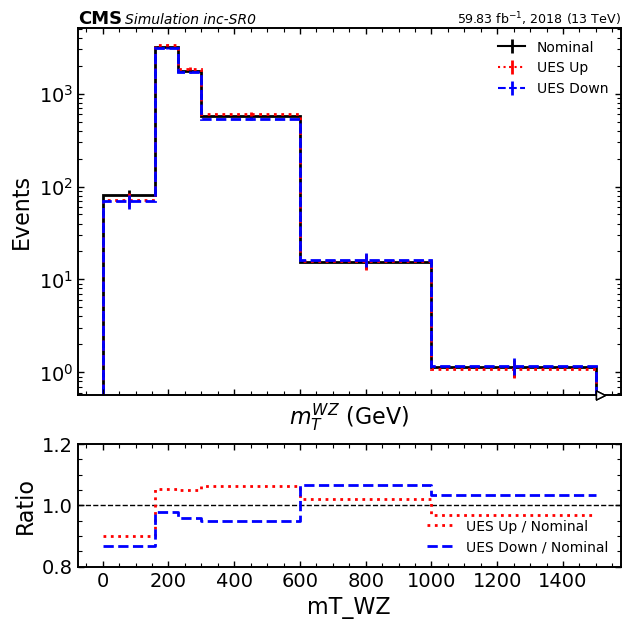

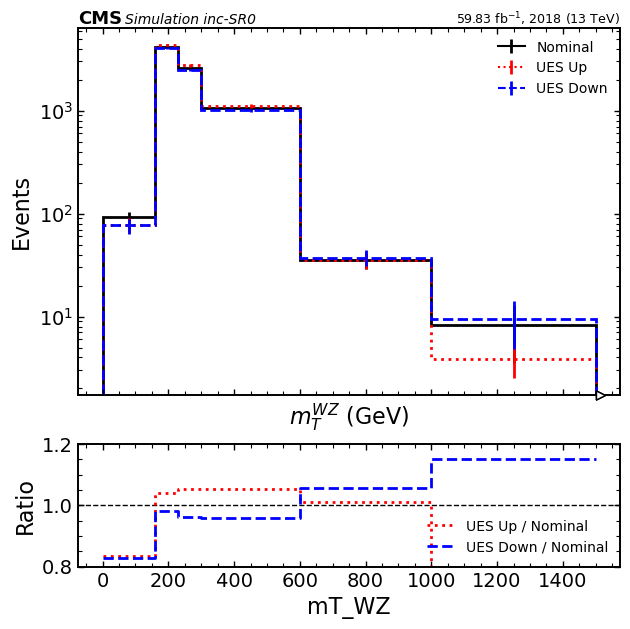

In [23]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
y = "2018"
c = "inc-SR0"
# v = "dilep_tau_loose_met_hadron_mt"
v = 'mT_WZ'
rrt = "datadriven"

for channel in config_2018.plotting:
    ch_cfg = config_2018.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2018, vname, channel,
             # rebin = v_cfg.rebin,
             # rebin = [10, 5, 5, 5, 5, 5, 5, 15, 20, 75], #fix for SR1
             rebin = [16, 7, 7, 30, 40, 50], #fix for SR0
             xlim = [],
             blind=v_cfg.blind,
             era = "2018",
             remap_replacement_types = rrt,
             #logx="logx",99o
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


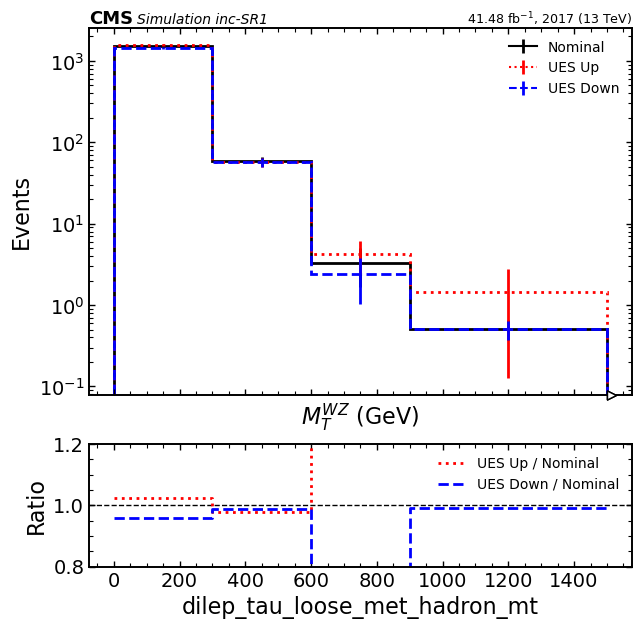

In [8]:
config_2017 = dctools.read_config("config/inc-WZ/input_UL_2017-WZ_inclusive.yaml")
y = "2017"
c = "inc-SR1"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2017.plotting:
    ch_cfg = config_2017.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2017, vname, channel,
             # rebin = v_cfg.rebin,
             rebin = [30, 30, 30, 60], #fix for SR1
             # rebin = [16, 7, 10, 16, 19, 82], #fix for SR0
             xlim = [],
             blind=v_cfg.blind,
             era = "2017",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()
/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


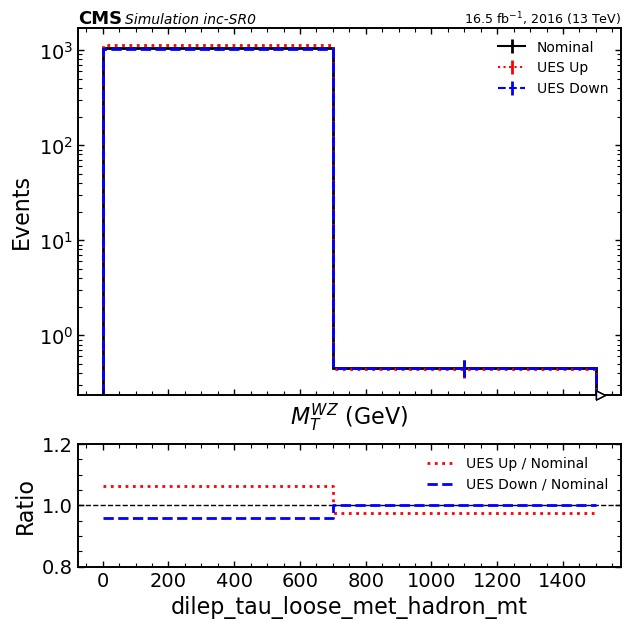

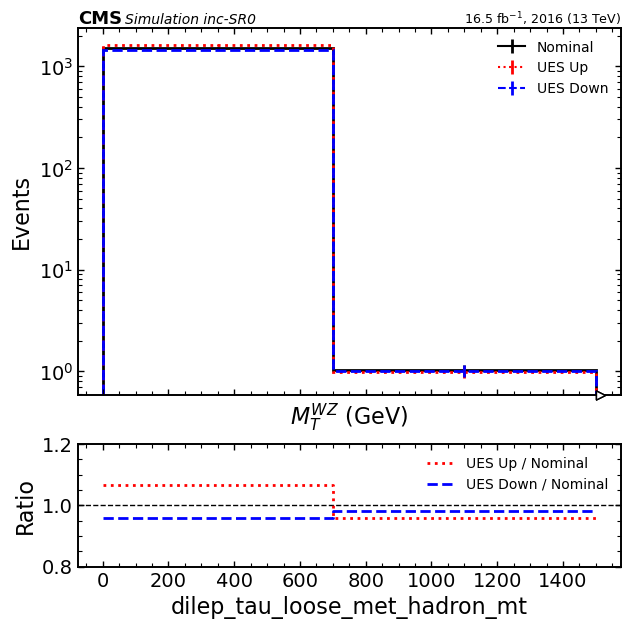

In [46]:
config_2016 = dctools.read_config("config/inc-WZ/input_UL_2016-WZ_inclusive.yaml")
y = "2016"
c = "inc-SR0"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2016.plotting:
    ch_cfg = config_2016.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2016, vname, channel,
             # rebin = v_cfg.rebin,
             rebin = [70, 80],
             # rebin = [16, 2, 2, 5, 5, 10, 10, 15, 20, 30, 35], #fix for SR0
             # rebin = [16, 2, 2, 3, 10, 12, 20, 20, 30, 35], #fix for SR1
             xlim = [],
             blind=v_cfg.blind,
             era = "2016",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()
/srv/DCTools/dctools/plot.py:91: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  storage = _h._storage_type()


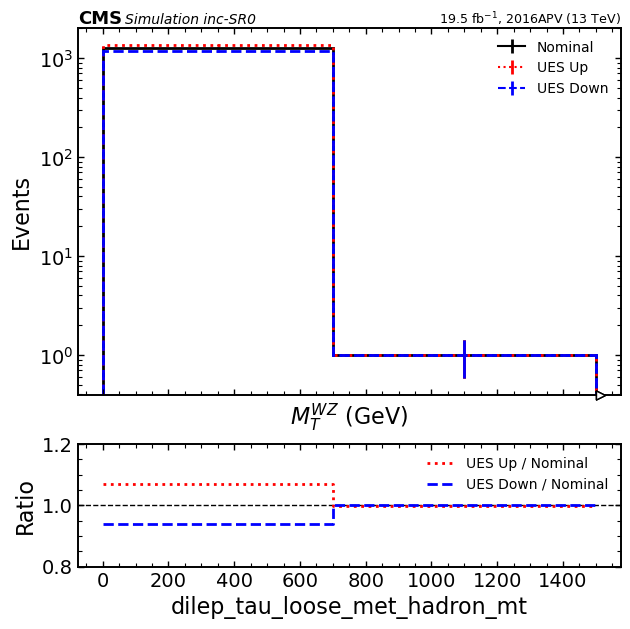

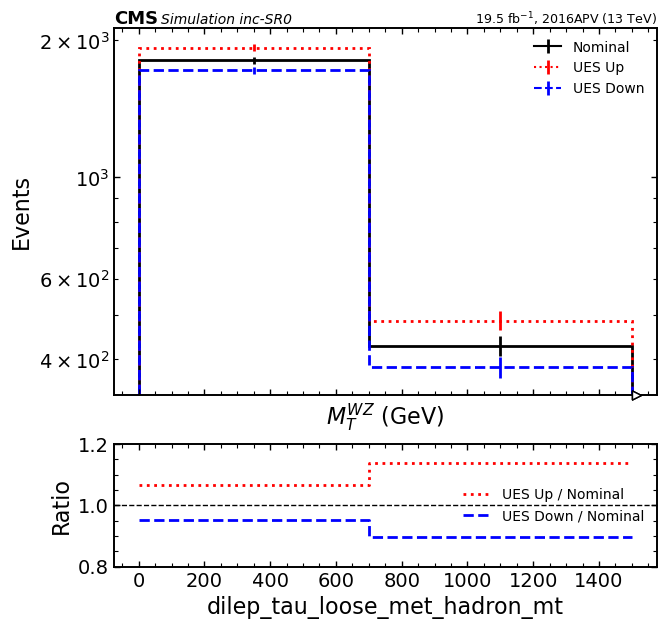

In [47]:
config_2016APV = dctools.read_config("config/inc-WZ/input_UL_2016APV-WZ_inclusive.yaml")
y = "2016APV"
c = "inc-SR0"
v = "dilep_tau_loose_met_hadron_mt"
# v = 'tau_pt_loose'
rrt = "datadriven"

for channel in config_2016APV.plotting:
    ch_cfg = config_2016APV.plotting[channel]
    if (c not in channel): continue
    for vname in ch_cfg:
        if v not in vname: continue
        v_cfg = ch_cfg[vname]
        plotting(config_2016APV, vname, channel,
             # rebin = v_cfg.rebin,
             rebin = [70, 80],
             # rebin = [16, 2, 2, 5, 5, 10, 10, 15, 20, 30, 35], #fix for SR0
             # rebin = [16, 2, 2, 3, 10, 12, 20, 20, 30, 35], #fix for SR1
             xlim = [],
             blind=v_cfg.blind,
             era = "2016APV",
             remap_replacement_types = rrt,
             #logx="logx",
             #bin_width_norm = "global_bin_width_norm",
             #no_ratios = "no_ratios",
             # checksyst = True,
             # combine_total_uncertainty = "combine_total_uncertainty",
             # combine_channel_group = None,
            )

In [8]:
config_2018 = dctools.read_config("config/inc-WZ/input_UL_2018-WZ_inclusive.yaml")
print(config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"])

Hist(
  StrCategory(['inc-SR1', 'inc-SR01', 'inc-DY0', 'inc-DY1', 'inc-DY01', 'inc-VB0', 'inc-VB1', 'inc-B0', 'inc-C0', 'inc-D0', 'inc-B1', 'inc-C1', 'inc-B01', 'inc-SR0', 'inc-VR0', 'inc-VR01', 'inc-VR1', 'inc-D1', 'inc-EM1', 'inc-EM0'], growth=True, name='channel'),
  StrCategory(['nominal', 'datadriven_DDDYNominalDown', 'datadriven_DDDYNominalUp', 'datadriven_DDDYDown', 'datadriven_DDDYUp'], growth=True, name='systematic'),
  Regular(60, 0, 180, name='dilep_m', label='$M_{\\ell\\ell}$ (GeV)'),
  storage=Weight()) # Sum: WeightedSum(value=725664, variance=681954) (WeightedSum(value=732429, variance=688314) with flow)


In [16]:
# h = config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"]
h = (
    config_2018.boosthist['DoubleMuon']["hist"]["dilep_m"]
    + config_2018.boosthist['MuonEG']["hist"]["dilep_m"]
    + config_2018.boosthist['SingleMuon']["hist"]["dilep_m"]
    + config_2018.boosthist['EGamma']["hist"]["dilep_m"]
)
h_sel = h[{"channel": "inc-VB0", "systematic": "datadriven_DDDYNominalUp"}]
print(h_sel)
print(h_sel.sum())
# Get bin centers and values
# values = h_sel.values()
# edges = h_sel.axes["dilep_m"].edges
# centers = 0.5 * (edges[1:] + edges[:-1])

# plt.step(centers, values, where="mid")
# plt.xlabel(r"$M_{\ell\ell}$ (GeV)")
# plt.ylabel("Events")
# plt.title("DoubleMuon - inc-VB0")
# plt.show()

                   ┌─────────────────────────────────────────────────────────┐
[-inf,   0) 0      │                                                         │
[   0,   3) 49.82  │█████▏                                                   │
[   3,   6) 19.99  │██                                                       │
[   6,   9) 11.68  │█▎                                                       │
[   9,  12) 14.21  │█▌                                                       │
[  12,  15) 9.019  │▉                                                        │
[  15,  18) 7.796  │▊                                                        │
[  18,  21) 6.684  │▋                                                        │
[  21,  24) 5.734  │▋                                                        │
[  24,  27) 5.919  │▋                                                        │
[  27,  30) 4.796  │▌                                                        │
[  30,  33) 4.494  │▌                               